# Notebook 3: GPR foreground removal

In this notebook, we will alternatively use GPR for foreground removal

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from meer21cm import MockSimulation
from meer21cm.plot import plot_map
from meer21cm.fg import ForegroundSimulation
from meer21cm.util import pca_clean
from gpr import *
from nautilus import Sampler, Prior
from scipy import optimize
from meer21cm.util import redshift_to_freq

In [2]:
import sys
import os
import importlib
#import functions # Replace with your actual file name
#importlib.reload(functions)
#from functions import *
from joblib import Parallel, delayed # this is for the multiprocessing but works with Jupyter notebooks
from tqdm import tqdm # this is to create a progress bar when running code 
import time

First, let us go back to the foreground and HI signal, and to see the structure of their covariances:

In [3]:
# Generate the mock and foreground signals
mock = MockSimulation(
    survey='meerklass_2021',
    band='L',
    flat_sky=True,
    seed=42,
    omega_hi=5e-4,
    mean_amp_1='average_hi_temp',
    tracer_bias_1=1.0,
)
fgsim = ForegroundSimulation(
    hp_nside=128,
    wproj=mock.wproj,
    num_pix_x=mock.num_pix_x,
    num_pix_y=mock.num_pix_y,
    backend='haslam',
    sp_indx_for_haslam_backend=-2.7,
)
hi_map = mock.propagate_mock_field_to_data(mock.mock_tracer_field_1)
fg_map = fgsim.fg_wcs_cube(mock.nu)


In [4]:
# extract their covariance 
cov_hi, _, _, _, = pca_clean(hi_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)
cov_fg, _, _, _, = pca_clean(fg_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)

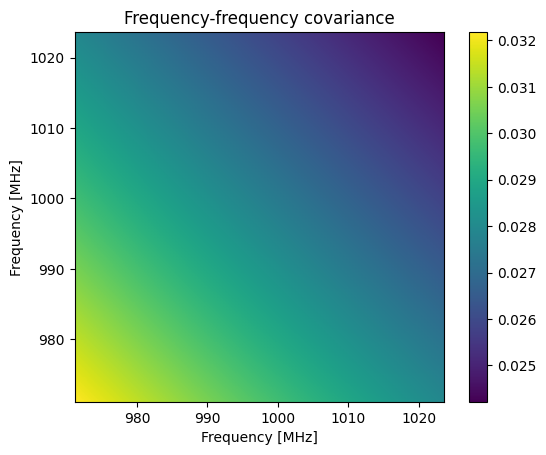

In [5]:
tot_map = hi_map + fg_map
cov_tot, _, eigen_values, _, = pca_clean(tot_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)
plt.imshow(cov_tot,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar()
plt.xlabel('Frequency [MHz]')
plt.ylabel('Frequency [MHz]')
plt.title('Frequency-frequency covariance')
#save_project_plot(plt.gcf(), week_number = 3, filename = "total_map_covariance.pdf")
plt.show()

NameError: name 'save_project_plot' is not defined

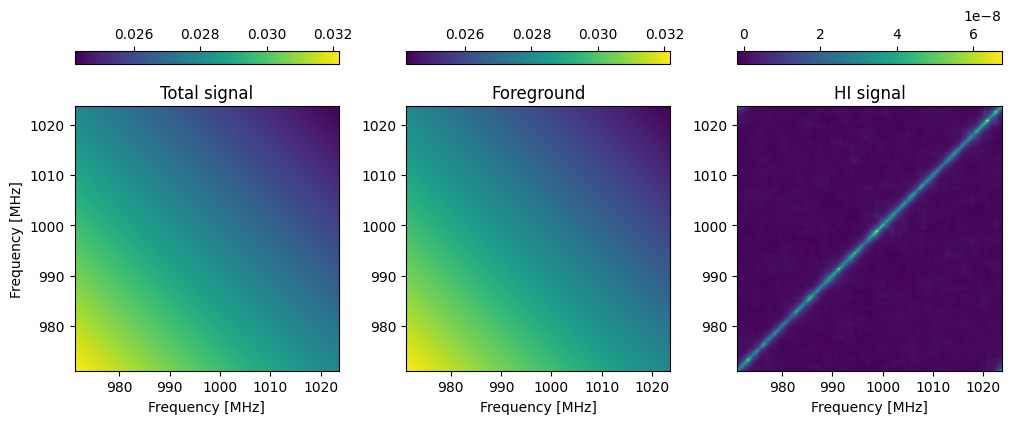

In [6]:
# plot the covariance of the HI and foreground signals
fig,axes = plt.subplots(1,3,figsize=(10,5), layout = "constrained")
im = axes[0].imshow(cov_tot,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top', pad = 0.05)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title('Total signal')

im = axes[1].imshow(cov_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top', pad = 0.05)
axes[1].set_xlabel('Frequency [MHz]')
#axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title('Foreground')

im = axes[2].imshow(cov_hi,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top', pad = 0.05)
axes[2].set_xlabel('Frequency [MHz]')
#axes[2].set_ylabel('Frequency [MHz]')
axes[2].set_title('HI signal')

save_project_plot(plt.gcf(), week_number = 6, filename = "tot_fg_hi_covariance.pdf")
plt.show()


In [ ]:
# plot the covariance of the HI and foreground signals
fig,axes = plt.subplots(1,2,figsize=(10,5))
im = axes[0].imshow(cov_hi,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top')
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title('HI covariance')

im = axes[1].imshow(cov_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top')
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title('Foreground covariance')
plt.show()

So we want two kernels that represent these two shown above. For example, let us check the exponential kernel first:

In [7]:
# create two exponential kernals
# one first l = 10, second with l = 100
exp_kern_1 = exponential_kernel(mock.nu/1e6,mock.nu/1e6,1,10)
exp_kern_2 = exponential_kernel(mock.nu/1e6,mock.nu/1e6,1,100)

Text(0.5, 1.0, '$l$ = 100 MHz')

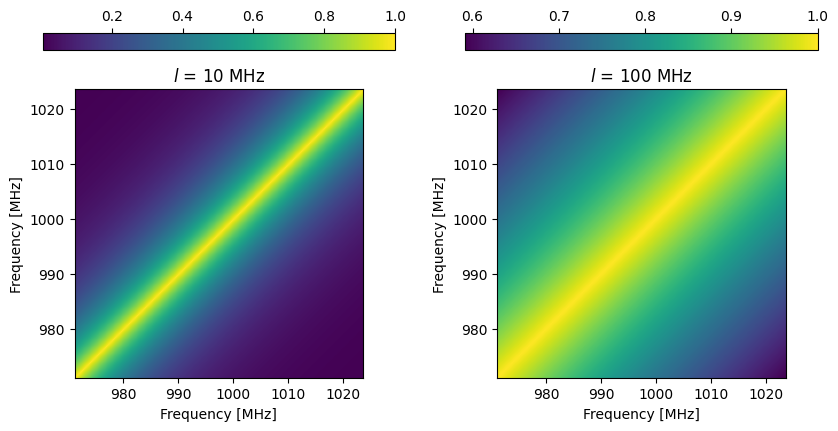

In [8]:
# plot the exponential kernals
fig,axes = plt.subplots(1,2,figsize=(10,5))
im = axes[0].imshow(exp_kern_1,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'$l$ = 10 MHz')

im = axes[1].imshow(exp_kern_2,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'$l$ = 100 MHz')


Ignore the amplitude for now, which I set to 1. I simply change $l$, which controls the width of the diagonal stripe as you can see. Larger the l (correlation length), wider the stripe. It is fairly obvious that for HI we need a very small length, say $l=1$ MHz: 

In [9]:
# test a rough estimate of the amplitude of the cov
sigma_hi_kern = np.sqrt(np.diagonal(cov_hi).mean())
l_hi = 1
exp_kern_hi = exponential_kernel(mock.nu/1e6,mock.nu/1e6,sigma_hi_kern,l_hi)


Text(0.5, 1.0, 'HI covariance')

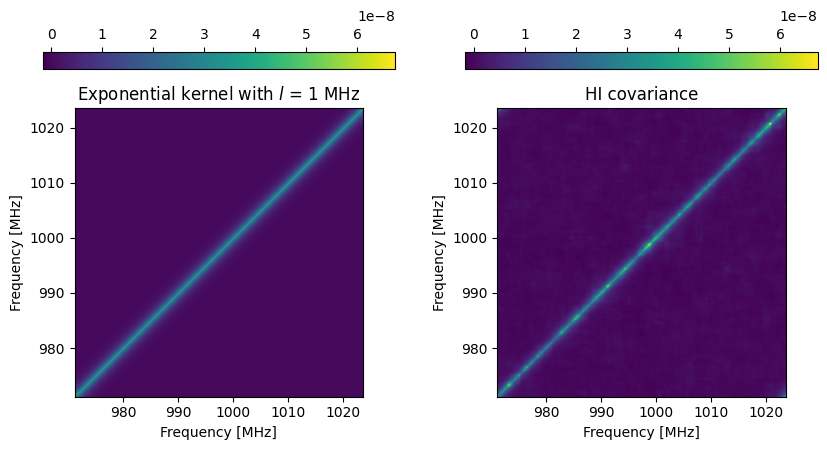

In [10]:
# plot the exponential kernal with l = 1 and the HI covariance
fig,axes = plt.subplots(1,2,figsize=(10,5))
vmin = np.min([exp_kern_hi.min(), cov_hi.min()])
vmax = np.max([exp_kern_hi.max(), cov_hi.max()])
im = axes[0].imshow(
    exp_kern_hi,origin='lower',
    extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],
    vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'Exponential kernel with $l$ = 1 MHz')

im = axes[1].imshow(
    cov_hi,origin='lower',
    extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],
    vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'HI covariance')


Now let us look at the foregrounds, which can be modelled by a RBF kernel:

In [11]:
# create two rbf kernals
# first with l = 10, second with l = 100
rbf_kern_1 = rbf_kernel(mock.nu/1e6,mock.nu/1e6,1,10)
rbf_kern_2 = rbf_kernel(mock.nu/1e6,mock.nu/1e6,1,100)

Text(0.5, 1.0, '$l$ = 100 MHz')

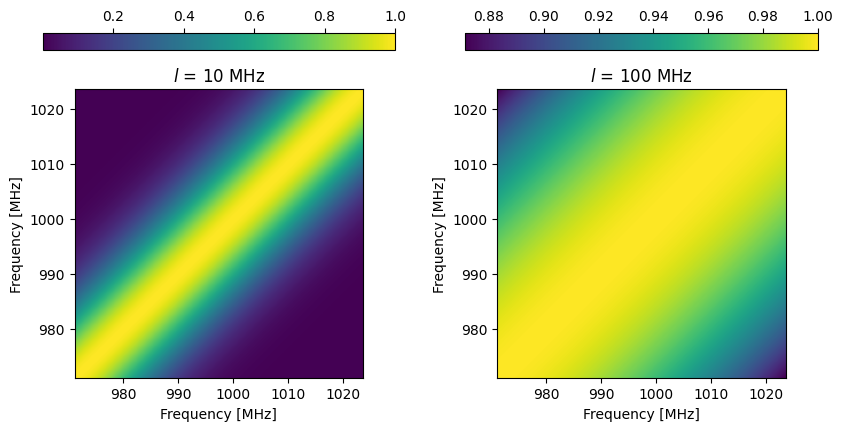

In [12]:
# plot the rbf kernals
fig,axes = plt.subplots(1,2,figsize=(10,5))
im = axes[0].imshow(rbf_kern_1,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'$l$ = 10 MHz')

im = axes[1].imshow(rbf_kern_2,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'$l$ = 100 MHz')


You can see the for a RBF kernel, the kernel is much wider than the exp kernel for the same correlation length. This is ideal to describe the smooth foregrounds.

0.16726389962495655


Text(0.5, 1.0, 'Foreground covariance')

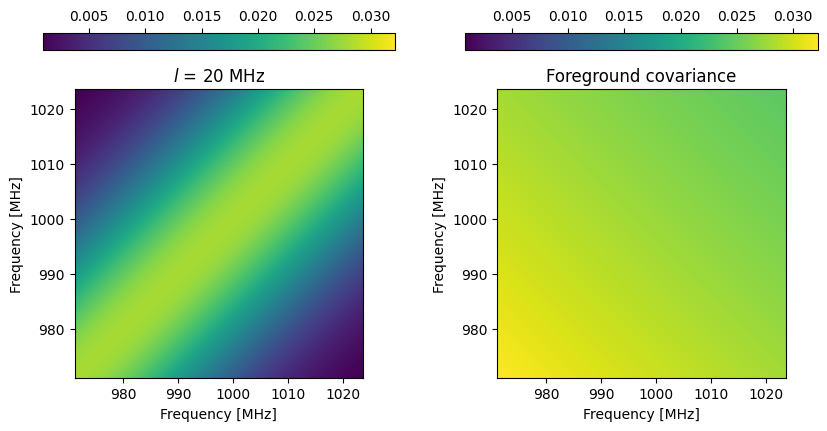

In [13]:
# plot the rbf kernal and the foreground covariance for comparison
sigma_fg_kern = np.sqrt(np.diagonal(cov_fg).mean())* 1.0
print(sigma_fg_kern)
l_fg = 20
rbf_kern_fg = rbf_kernel(mock.nu/1e6,mock.nu/1e6,sigma_fg_kern,l_fg)
vmin = np.min([rbf_kern_fg.min(), cov_fg.min()])
vmax = np.max([rbf_kern_fg.max(), cov_fg.max()])
fig,axes = plt.subplots(1,2,figsize=(10,5))
im = axes[0].imshow(rbf_kern_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'$l$ = 20 MHz')

im = axes[1].imshow(cov_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title('Foreground covariance')



However, this is still not quite matching. The problem is, the foreground has something called spectral index. That is to say, the brightness of the foreground scales according to frequency:

$$
T(f) = T_0(f_0) * (f/f_0)^\gamma
$$

This is where we want to improve from the previous work. In the RBF kernel, I allow an additional input $\gamma$:

Text(0.5, 1.0, 'Foreground covariance')

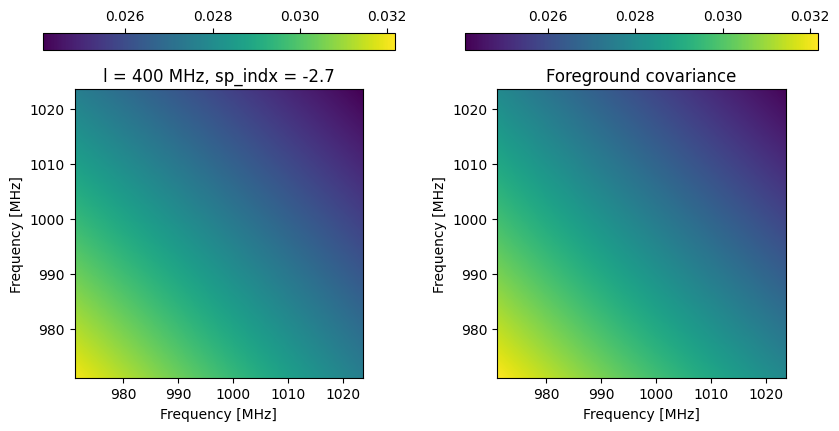

In [14]:
sigma_fg_kern = np.sqrt(np.diagonal(cov_fg).mean())* 1.07
l_fg = 400
sp_indx_fg = -2.7
rbf_kern_fg = rbf_kernel(mock.nu/1e6,mock.nu/1e6,sigma_fg_kern,l_fg,sp_indx_fg)
vmin = np.min([rbf_kern_fg.min(), cov_fg.min()])
vmax = np.max([rbf_kern_fg.max(), cov_fg.max()])
fig,axes = plt.subplots(1,2,figsize=(10,5))
im = axes[0].imshow(rbf_kern_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(f'l = {l_fg} MHz, sp_indx = {sp_indx_fg}')

im = axes[1].imshow(cov_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title('Foreground covariance')



As you can see, it starts to resemble the foreground covariance.

Furthermore, we need to add in the thermal noise. There are more physical ways of generating the noise, but for now let us just add in a Gaussian noise with a standard deviation that I take from 2407.21626

In [15]:
# generate gaussian note and extract its covariance
sigma_noise = 1.21 * 1e-3
noise_map = np.random.default_rng(mock.seed).normal(0,sigma_noise,hi_map.shape) * mock.w_HI
cov_noise,_,_,_ = pca_clean(noise_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)

As we have discussed, the noise covariance should be purely diagonal:

Text(0.5, 1.0, 'Noise covariance')

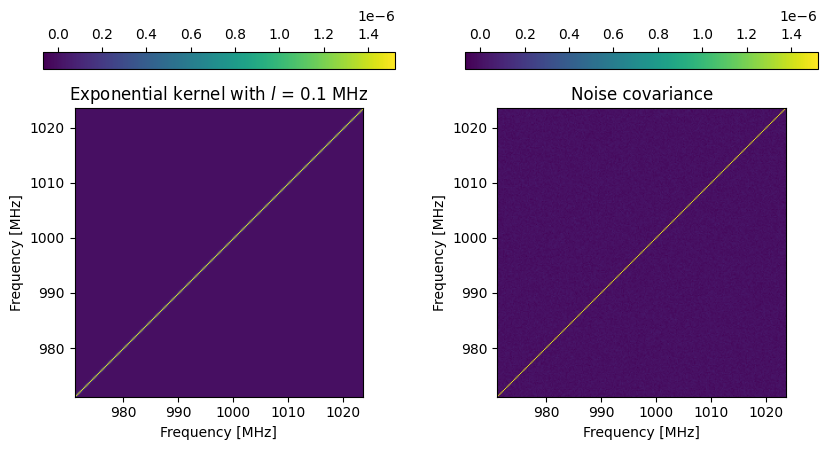

In [16]:
# plot the exponent kernal with l = 0.1 and the noise covariance
exp_kern_noise = exponential_kernel(mock.nu/1e6,mock.nu/1e6,sigma_noise,0.1)
fig,axes = plt.subplots(1,2,figsize=(10,5))
vmin = np.min([exp_kern_noise.min(), cov_noise.min()])
vmax = np.max([exp_kern_noise.max(), cov_noise.max()])
im = axes[0].imshow(
    exp_kern_noise,origin='lower',
    extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],
    vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'Exponential kernel with $l$ = 0.1 MHz')

im = axes[1].imshow(
    cov_noise,origin='lower',
    extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],
    vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'Noise covariance')


Note that this is just for illustration. To find the true kernel, we need to perform the optimisation routine to find the kernel parameters. See Eq 18.

In [17]:
tot_map = hi_map + fg_map + noise_map

In [18]:
cov_tot,_,_,_ = pca_clean(tot_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)

Now, let us try to find the best fit parameter for the GPR:

In [19]:
best_fit = optimize.fmin(function_to_optimise,[sigma_noise,sigma_fg_kern*1.02,l_hi,l_fg,sp_indx_fg],args=(mock.nu/1e6, cov_tot,True))

/Users/gracetait/shproject/senior_honours_project/notebooks/week5/gpr.py:33: RuntimeWarning: overflow encountered in exp
  return np.nan_to_num(sigma**2 * np.exp(-np.abs(x-y)/l))
/opt/anaconda3/envs/meer21cm/lib/python3.10/site-packages/numpy/linalg/linalg.py:2120: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/meer21cm/lib/python3.10/site-packages/numpy/linalg/linalg.py:2120: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/var/folders/1y/bkp6bf212cl3sq0d7bgcgtvm0000gn/T/ipykernel_57525/4092381761.py:1: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  best_fit = optimize.fmin(function_to_optimise,[sigma_noise,sigma_fg_kern*1.02,l_hi,l_fg,sp_indx_fg],args=(mock.nu/1e6, cov_tot,True))


In [20]:
fitted_pars = best_fit
fitted_hi_kern = exponential_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[0], fitted_pars[2])
fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], fitted_pars[4])

Text(0.5, 1.0, 'Noise covariance')

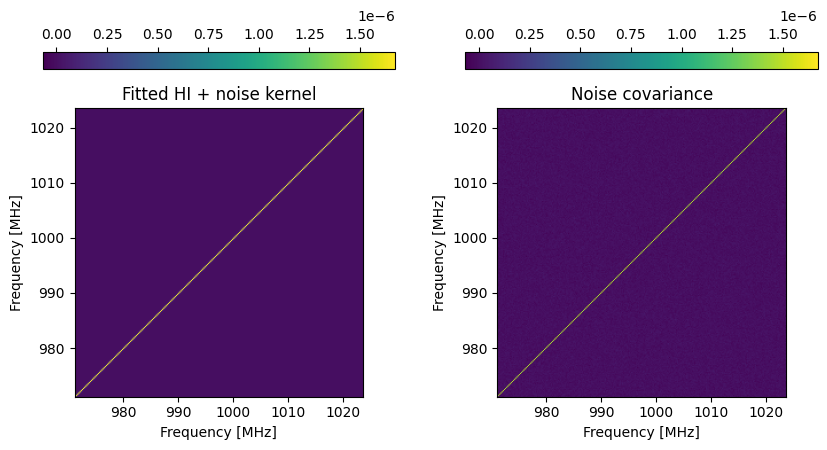

In [21]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
vmin = np.min([fitted_hi_kern.min(), cov_noise.min()])
vmax = np.max([fitted_hi_kern.max(), cov_noise.max()])
im = axes[0].imshow(fitted_hi_kern,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'Fitted HI + noise kernel')

im = axes[1].imshow(cov_noise,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'Noise covariance')



Text(0.5, 1.0, 'Foreground covariance')

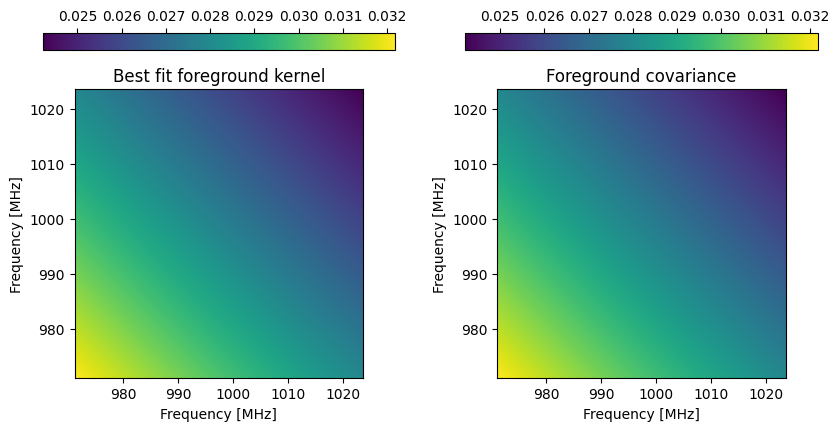

In [22]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
vmin = np.min([fitted_fg_kern.min(), cov_fg.min()])
vmax = np.max([fitted_fg_kern.max(), cov_fg.max()])
im = axes[0].imshow(fitted_fg_kern,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'Best fit foreground kernel')

im = axes[1].imshow(cov_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'Foreground covariance')



Now, with the fitted foreground kernel, we can remove the foreground from the data:

In [23]:
fg_remov = np.einsum(
    'ij, abj->abi',
    fitted_fg_kern @ np.linalg.inv(fitted_fg_kern + fitted_hi_kern),
    tot_map
)
res_map = tot_map - fg_remov

In [24]:
noise_residual = np.einsum(
    'ij, abj->abi',
    np.eye(mock.nu.size) - fitted_fg_kern @ np.linalg.inv(fitted_fg_kern+fitted_hi_kern),
    noise_map
)

Now let us see the removed map versus the actual map:

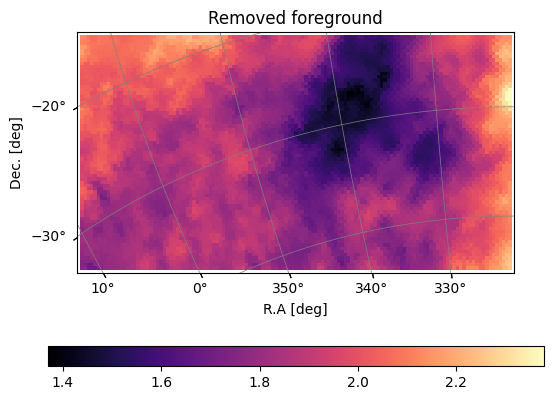

In [25]:
plot_map(fg_remov,mock.wproj,W=mock.W_HI, title='Removed foreground')

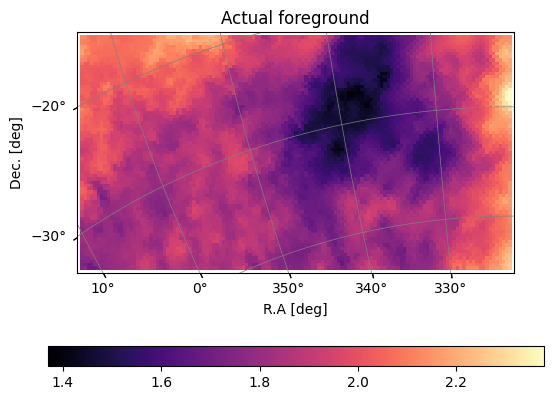

In [26]:
plot_map(fg_map,mock.wproj,W=mock.W_HI, title='Actual foreground')

As you can see the removal is quite good.

Let us check the power spectrum:

In [27]:
mock.kparabins = np.linspace(0.01, 1, 11)
mock.kperpbins = np.linspace(0.01, 0.5, 21)
mock.k1dbins = np.linspace(0, 1.2, 21)

In [28]:
mock.data = hi_map
mock.grid_data_to_field();
power_cy_hi,_ = mock.get_cy_power(mock.auto_power_3d_1)
power_1d_hi,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
mock.data = res_map
mock.grid_data_to_field();
power_cy_res,_ = mock.get_cy_power(mock.auto_power_3d_1)
power_1d_res,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
mock.data = noise_residual
mock.grid_data_to_field();
power_cy_noise,_ = mock.get_cy_power(mock.auto_power_3d_1)
power_1d_noise,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
power_cy_res -= power_cy_noise
power_1d_res -= power_1d_noise
# Here we add in the noise, so we need to subtract out the noise power
# in real data analysis noise power can be calculated from the noise sigma

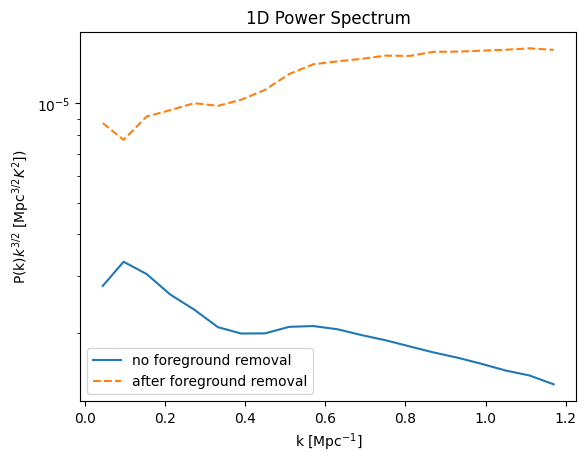

In [29]:
plt.plot(k_1d, (power_1d_hi.T)*k_1d**(3/2),label='no foreground removal')
plt.plot(k_1d, (power_1d_res.T)*k_1d**(3/2),label='after foreground removal',ls='--')
plt.xlabel('k [Mpc$^{-1}$]')
plt.ylabel(r'P(k)$k^{3/2}$ [${\rm Mpc}^{3/2}K^2]$)')
plt.yscale('log')
plt.title('1D Power Spectrum')
plt.legend()



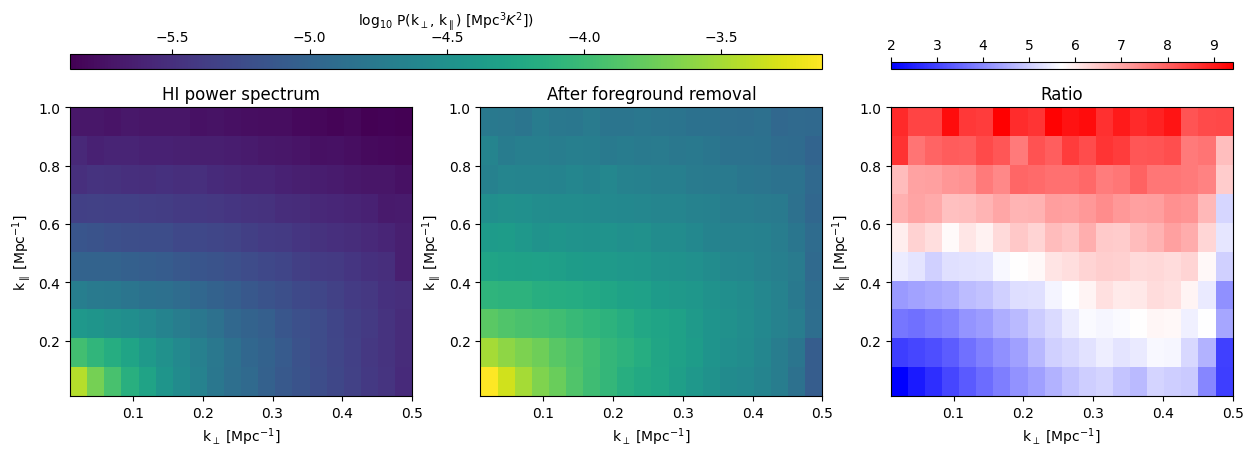

In [30]:
vmin = np.log10([power_cy_hi.min(),power_cy_res.min()]).min()
vmax = np.log10([power_cy_hi.max(),power_cy_res.max()]).max()   
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi.T),vmin=vmin,vmax=vmax)
axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[0].set_title('HI power spectrum')
im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res.T),vmin=vmin,vmax=vmax)
axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[1].set_title('After foreground removal')
cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.1)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)')
im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res.T/power_cy_hi.T),cmap='bwr')
axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[2].set_title('Ratio')
cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.1)
plt.show()

Things for you to try:
1. Play with the kernels and understand the kernel functions
2. Can you find a better optimisation routine to achieve a better result?

# My code

## Define functions

In [48]:
def plot_HI_signal_kernal_comparison(fitted_pars, method, save_plot = False, week_number = None):

    # generate gaussian noise and extract its covariance
    sigma_noise = 1.21 * 1e-3
    noise_map = np.random.default_rng(mock.seed).normal(0,sigma_noise,hi_map.shape) * mock.w_HI
    cov_noise,_,_,_ = pca_clean(noise_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)

    # create hi signal kernal using exponential kernal and best fit parameters
    fitted_hi_kern = exponential_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[0], fitted_pars[2])

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout = "constrained")
    
    im = axes[0].imshow(fitted_hi_kern, origin='lower',
                        extent=[mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6])
    plt.colorbar(im, location='right', fraction = 0.05)
    axes[0].set_xlabel('Frequency [MHz]')
    axes[0].set_ylabel('Frequency [MHz]')
    axes[0].set_title(r'Fitted HI + noise kernel')
    
    im = axes[1].imshow(cov_noise, origin='lower',
                        extent=[mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6])
    plt.colorbar(im, location='right', fraction = 0.05)
    axes[1].set_xlabel('Frequency [MHz]')
    axes[1].set_ylabel('Frequency [MHz]')
    axes[1].set_title(r'Noise covariance')

    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"hi_signal_kernal_comparison_{method}.pdf")
    
    #plt.tight_layout()
    plt.show()

In [49]:
def plot_foreground_signal_kernal_comparison(fitted_pars, method, save_plot = False, week_number = None, sp_indx_fg = True,
                                            kernel = rbf_kernel, eta = 0.0):

    fitted_hi_kern = exponential_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[0], fitted_pars[2])

    if kernel == rbf_kernel and sp_indx_fg == True:
        fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], fitted_pars[4])
    
    if kernel == rbf_kernel and sp_indx_fg == False:
        fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3])

    if kernel == matern_kernel and eta == 5/2:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)

    if kernel == matern_kernel and eta == 3/2:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)

    if kernel == matern_kernel:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)
    
    # plot the best fitted kernal and foreground covariance with independent colour scales
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout = "constrained")
    im = axes[0].imshow(fitted_fg_kern, origin='lower', extent=[mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6])
    plt.colorbar(im, location='right', fraction = 0.05)
    axes[0].set_xlabel('Frequency [MHz]')
    axes[0].set_ylabel('Frequency [MHz]')
    axes[0].set_title(r'Best fit foreground kernel')
    
    im = axes[1].imshow(cov_fg, origin='lower', extent=[mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6])
    plt.colorbar(im, location='right', fraction = 0.05)
    axes[1].set_xlabel('Frequency [MHz]')
    axes[1].set_ylabel('Frequency [MHz]')
    axes[1].set_title(r'Foreground covariance')

    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"fg_signal_kernal_comparison_{method}.pdf")
    
    #plt.tight_layout()
    plt.show()

In [42]:
def foreground_kernal_removal_plots(fitted_pars, method, save_plot = False, week_number = None, sp_indx_fg = True,
                                   kernel = rbf_kernel, eta = 0.0):

    fitted_hi_kern = exponential_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[0], fitted_pars[2])

    if kernel == rbf_kernel and sp_indx_fg == True:
        fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], fitted_pars[4])
    
    if kernel == rbf_kernel and sp_indx_fg == False:
        fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3])

    if kernel == matern_kernel and eta == 5/2:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)

    if kernel == matern_kernel and eta == 3/2:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)
        
    if kernel == matern_kernel:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)
        
    fg_remov = np.einsum(
    'ij, abj->abi',
    fitted_fg_kern @ np.linalg.inv(fitted_fg_kern + fitted_hi_kern),
    tot_map
    )
    res_map = tot_map - fg_remov

    noise_residual = np.einsum(
    'ij, abj->abi',
    np.eye(mock.nu.size) - fitted_fg_kern @ np.linalg.inv(fitted_fg_kern+fitted_hi_kern),
    noise_map
    )

    plot_map(fg_remov,mock.wproj,W=mock.W_HI, title='Removed foreground')

    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"removed_kernal_foreground_{method}.pdf")

    plot_map(fg_map,mock.wproj,W=mock.W_HI, title='Actual foreground')

    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"removed_actual_foreground_{method}.pdf")

In [43]:
def kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method, save_plot = False, week_number = None, sp_indx_fg = True, 
                                                                power_spectrum = True, log_power_spectrum = True, cylindrical_power_spectrum = True,
                                                               kernel = rbf_kernel, eta = 0.0):

    fitted_hi_kern = exponential_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[0], fitted_pars[2])

    if kernel == rbf_kernel and sp_indx_fg == True:
        fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], fitted_pars[4])
    
    if kernel == rbf_kernel and sp_indx_fg == False:
        fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3])

    if kernel == matern_kernel and eta == 5/2:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)

    if kernel == matern_kernel and eta == 3/2:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)
    
    if kernel == matern_kernel:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)

    fg_remov = np.einsum(
    'ij, abj->abi',
    fitted_fg_kern @ np.linalg.inv(fitted_fg_kern + fitted_hi_kern),
    tot_map
    )
    res_map = tot_map - fg_remov

    noise_residual = np.einsum(
    'ij, abj->abi',
    np.eye(mock.nu.size) - fitted_fg_kern @ np.linalg.inv(fitted_fg_kern+fitted_hi_kern),
    noise_map
    )

    mock.kparabins = np.linspace(0.01, 1, 11)
    mock.kperpbins = np.linspace(0.01, 0.5, 21)
    mock.k1dbins = np.linspace(0, 1.2, 21)

    mock.data = hi_map
    mock.grid_data_to_field();
    power_cy_hi,_ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_hi,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
    mock.data = res_map
    mock.grid_data_to_field();
    power_cy_res,_ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_res,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
    mock.data = noise_residual
    mock.grid_data_to_field();
    power_cy_noise,_ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_noise,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
    power_cy_res -= power_cy_noise
    power_1d_res -= power_1d_noise
    # Here we add in the noise, so we need to subtract out the noise power
    # in real data analysis noise power can be calculated from the noise sigma

    if power_spectrum == True:
        # 1D power spectrum
        plt.plot(k_1d, (power_1d_hi.T)*k_1d**(3/2),label='no foreground removal', color = 'blue')
        plt.plot(k_1d, (power_1d_res.T)*k_1d**(3/2),label='after foreground removal',ls='--', color = 'red')
        plt.xlabel('k [Mpc$^{-1}$]')
        plt.ylabel(r'P(k)$k^{3/2}$ [${\rm Mpc}^{3/2}K^2]$)')
        plt.title('1D Power Spectrum')
        plt.legend()
        if save_plot:
            save_project_plot(plt.gcf(), week_number=week_number,
                              filename=f"1d_power_spectrum_{method}.pdf")
        plt.show()

    if log_power_spectrum == True:
        # log 1D power spectrum
        log_power_1d_hi = np.log10(power_1d_hi)
        log_power_1d_res = np.log10(power_1d_res)
        plt.plot(k_1d, log_power_1d_hi, label='no foreground removal', color = 'blue', linewidth = 1)
        plt.plot(k_1d, log_power_1d_res, label='after foreground removal',ls='--', color = 'red', linewidth = 1)
        plt.xlabel('k [Mpc$^{-1}$]')
        plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)')
        plt.title('1D Power Spectrum')
        plt.legend()
        # save plot
        if save_plot == True:
            save_project_plot(plt.gcf(), week_number = week_number, 
                              filename = f"log_1d_power_spectrum_{method}.pdf") 
        plt.show()

    if cylindrical_power_spectrum == True:
        # cylindrical power spectrum
        vmin = np.log10([power_cy_hi.min(),power_cy_res.min()]).min()
        vmax = np.log10([power_cy_hi.max(),power_cy_res.max()]).max()   
        fig,axes=plt.subplots(1,3,figsize=(15,5), layout = "constrained")
        axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi.T),vmin=vmin,vmax=vmax)
        axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
        axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
        axes[0].set_title('HI power spectrum')
        im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res.T),vmin=vmin,vmax=vmax)
        axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
        axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
        axes[1].set_title('After foreground removal')
        cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.1)
        cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)')
        im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res.T/power_cy_hi.T),cmap='bwr')
        axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
        axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
        axes[2].set_title('Ratio')
        cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.1)
        # save plot
        if save_plot == True:
            save_project_plot(plt.gcf(), week_number = week_number, 
                              filename = f"cylindrical_power_spectrum_{method}.pdf")
        plt.show()

In [35]:
# copy and paste in function which makes saving files easier
def save_project_plot(fig, week_number, filename):
    """
    Saves a matplotlib figure to a specific week's folder.
    Example: week_number=1 saves to .../outputs/week1/
    """
    # 1. Define the base path
    base_path = "/Users/gracetait/shproject/senior_honours_project/outputs"
    
    # 2. Create the week-specific folder name
    week_folder = f"week{week_number}"
    
    # 3. Combine them into a full path
    target_dir = os.path.join(base_path, week_folder)
    
    # 4. Create the directory if it doesn't exist yet
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
        print(f"Created new directory: {target_dir}")
    
    # 5. Define the final file path
    save_path = os.path.join(target_dir, filename)
    
    # 6. Save the figure
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Successfully saved: {save_path}")

In [36]:
# generate a list of 100 integers [1, 2, 3, ..., 100]
seeds = np.arange(1, 101)

# Trying different kernels

## eta = ?

In [43]:
tot_map = hi_map + fg_map + noise_map
#tot_map = hi_map + fg_map
cov_tot, __, __, __ = pca_clean(tot_map, 1, weights = mock.w_HI, return_analysis = True, mean_center = True)

In [37]:
# lets try a different scipy optimise function = minimize
#x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
eta = 0
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, eta], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = bounds = [
    (1e-6, 0.5),   # Amplitudes must be positive
    (1e-6, 0.5), 
    (0.01, 2.0),  # hi length scale (MHz)
    (10.0, 1000.0),  # foreground length scale (MHz)
    (0.1, 1000.0)
    #(-5, -0.1)    # spectral index can be anything
]
best_fit = optimize.minimize(fun = function_to_optimise_matern, x0 = x0, args = args, bounds = bounds, method = 'Nelder-Mead',
    options={'maxiter': 2000, 'maxfev': 5000}) #  method = 'Nelder-Mead'

/var/folders/1y/bkp6bf212cl3sq0d7bgcgtvm0000gn/T/ipykernel_57525/654101921.py:14: OptimizeWarning: Initial guess is not within the specified bounds
  best_fit = optimize.minimize(fun = function_to_optimise_matern, x0 = x0, args = args, bounds = bounds, method = 'Nelder-Mead',
/Users/gracetait/shproject/senior_honours_project/notebooks/week5/gpr.py:8: RuntimeWarning: invalid value encountered in multiply
  sigma**2


In [38]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: Optimization terminated successfully.
Optimized Parameters: [1.28945602e-03 2.47030016e-01 1.00000000e-02 1.00000000e+03
 1.92027433e+00]
Log-Marginial Likeligood: -1537.0906076754234


In [39]:
print(x0)
print(fitted_pars)

[1.90448375e-04 1.82551820e-01 1.00000000e+00 4.00000000e+02
 0.00000000e+00]
[1.28945602e-03 2.47030016e-01 1.00000000e-02 1.00000000e+03
 1.92027433e+00]


In [53]:
#plot_HI_signal_kernal_comparison(fitted_pars, method = "eta_free_param_nelder_mead", save_plot = True, week_number =8)
#plot_foreground_signal_kernal_comparison(fitted_pars, method = "eta_free_param_nelder_mead", save_plot = True, week_number = 8, sp_indx_fg = True, 
#                                        kernel = matern_kernel, eta = fitted_pars[-1])
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds1", save_plot = False, week_number = 5, sp_indx_fg = True)

In [54]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "eta_free_param_nelder_mead", save_plot = True, week_number = 5, 
#                                                            sp_indx_fg = True, kernel = matern_kernel, eta = fitted_pars[-1])

## eta = 5/2 (not good)

In [55]:
tot_map = hi_map + fg_map + noise_map
#tot_map = hi_map + fg_map
cov_tot, __, __, __ = pca_clean(tot_map, 1, weights = mock.w_HI, return_analysis = True, mean_center = True)

In [56]:
# lets try a different scipy optimise function = minimize
#x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
eta = 5/2
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = bounds = [
    (1e-6, 0.5),   # Amplitudes must be positive
    (1e-6, 0.5), 
    (0.01, 2.0),  # hi length scale (MHz)
    (10.0, 1000.0)  # foreground length scale (MHz)
    #(0.1, 1000.0)
    #(-5, -0.1)    # spectral index can be anything
]
best_fit = optimize.minimize(fun = function_to_optimise_matern_5_2, x0 = x0, args = args, bounds = bounds, method = 'Nelder-Mead',
    options={'maxiter': 2000, 'maxfev': 5000}) #  method = 'Nelder-Mead'

/Users/gracetait/shproject/senior_honours_project/notebooks/week5/gpr.py:8: RuntimeWarning: invalid value encountered in multiply
  sigma**2


In [57]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: Optimization terminated successfully.
Optimized Parameters: [1.29078798e-03 2.11889596e-01 1.00000000e-02 6.54747572e+02]
Log-Marginial Likeligood: -1537.0704133254599


In [58]:
print(x0)
print(fitted_pars)

[1.90448375e-04 1.82551820e-01 1.00000000e+00 4.00000000e+02]
[1.29078798e-03 2.11889596e-01 1.00000000e-02 6.54747572e+02]


In [65]:
#plot_HI_signal_kernal_comparison(fitted_pars, method = "eta_5_2_nelder_mead", save_plot = True, week_number = 8)
#plot_foreground_signal_kernal_comparison(fitted_pars, method = "eta_5_2_nelder_mead", save_plot = True, week_number = 8, sp_indx_fg = True, 
#                                        kernel = matern_kernel, eta = 5/2)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds1", save_plot = False, week_number = 5, sp_indx_fg = True)

In [66]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "eta_5_2_nelder_mead", save_plot = True, week_number = 8, 
#                                                            sp_indx_fg = True, kernel = matern_kernel, eta = 5_2)

## eta = 3/2 (not good)

In [67]:
tot_map = hi_map + fg_map + noise_map
#tot_map = hi_map + fg_map
cov_tot, __, __, __ = pca_clean(tot_map, 1, weights = mock.w_HI, return_analysis = True, mean_center = True)

In [68]:
# lets try a different scipy optimise function = minimize
#x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
eta = 3/2
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = bounds = [
    (1e-6, 0.5),   # Amplitudes must be positive
    (1e-6, 0.5), 
    (0.01, 2.0),  # hi length scale (MHz)
    (10.0, 1000.0)  # foreground length scale (MHz)
    #(0.1, 1000.0)
    #(-5, -0.1)    # spectral index can be anything
]
best_fit = optimize.minimize(fun = function_to_optimise_matern_3_2, x0 = x0, args = args, bounds = bounds, method = 'Nelder-Mead',
    options={'maxiter': 2000, 'maxfev': 5000}) #  method = 'Nelder-Mead'

/Users/gracetait/shproject/senior_honours_project/notebooks/week5/gpr.py:8: RuntimeWarning: invalid value encountered in multiply
  sigma**2


In [69]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: Optimization terminated successfully.
Optimized Parameters: [1.28536013e-03 1.78075803e-01 1.00000000e-02 1.00000000e+03]
Log-Marginial Likeligood: -1536.610189052921


In [70]:
print(x0)
print(fitted_pars)

[1.90448375e-04 1.82551820e-01 1.00000000e+00 4.00000000e+02]
[1.28536013e-03 1.78075803e-01 1.00000000e-02 1.00000000e+03]


In [74]:
#plot_HI_signal_kernal_comparison(fitted_pars, method = "eta_3_2_nelder_mead", save_plot = True, week_number = 8)
#plot_foreground_signal_kernal_comparison(fitted_pars, method = "eta_3_2_nelder_mead", save_plot = True, week_number = 8, sp_indx_fg = True, 
#                                        kernel = matern_kernel, eta = 3/2)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds1", save_plot = False, week_number = 5, sp_indx_fg = True)

In [75]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "eta_5_2_nelder_mead", save_plot = True, week_number = 8, 
#                                                            sp_indx_fg = True, kernel = matern_kernel, eta = 3_2)

## Scipy optimise minimise 1

In [82]:
tot_map = hi_map + fg_map + noise_map
#tot_map = hi_map + fg_map
cov_tot, __, __, __ = pca_clean(tot_map, 1, weights = mock.w_HI, return_analysis = True, mean_center = True)

In [83]:
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
#x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = bounds = [
    (1e-6, 0.5),   # Amplitudes must be positive
    (1e-6, 0.5), 
    (0.01, 2.0),  # hi length scale (MHz)
    (10.0, 1000.0),  # foreground length scale (MHz)
    (-5, -0.1)    # spectral index can be anything
]
best_fit = optimize.minimize(fun = function_to_optimise, x0 = x0, args = args, bounds = bounds, method = 'Nelder-Mead',
    options={'maxiter': 2000, 'maxfev': 5000}) #  method = 'Nelder-Mead'

In [84]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: Optimization terminated successfully.
Optimized Parameters: [ 1.29240549e-03  1.27862972e-01  1.00000000e-02  9.99999999e+02
 -2.72572866e+00]
Log-Marginial Likeligood: -1539.7033506545201


In [85]:
print(x0)
print(fitted_pars)

[ 1.90448375e-04  1.82551820e-01  1.00000000e+00  4.00000000e+02
 -2.70000000e+00]
[ 1.29240549e-03  1.27862972e-01  1.00000000e-02  9.99999999e+02
 -2.72572866e+00]


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/hi_signal_kernal_comparison_default_with_bounds1.pdf


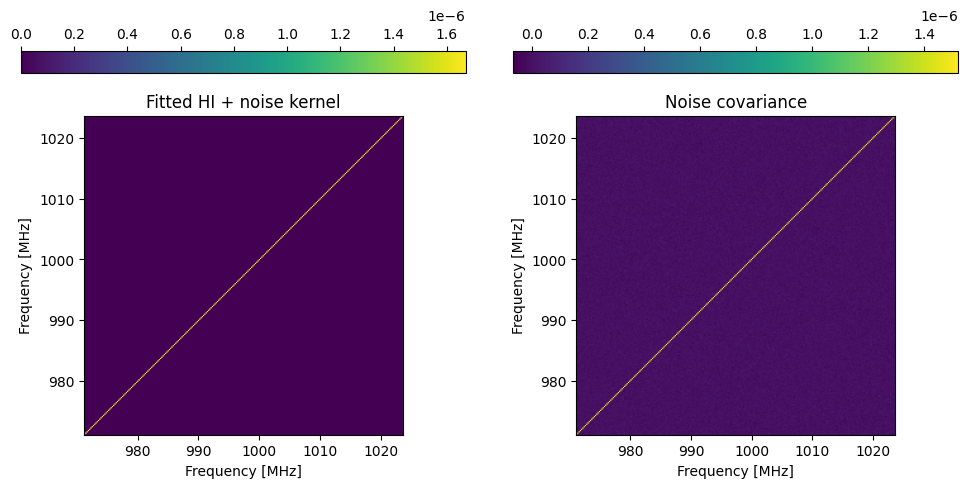

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/fg_signal_kernal_comparison_default_with_bounds1.pdf


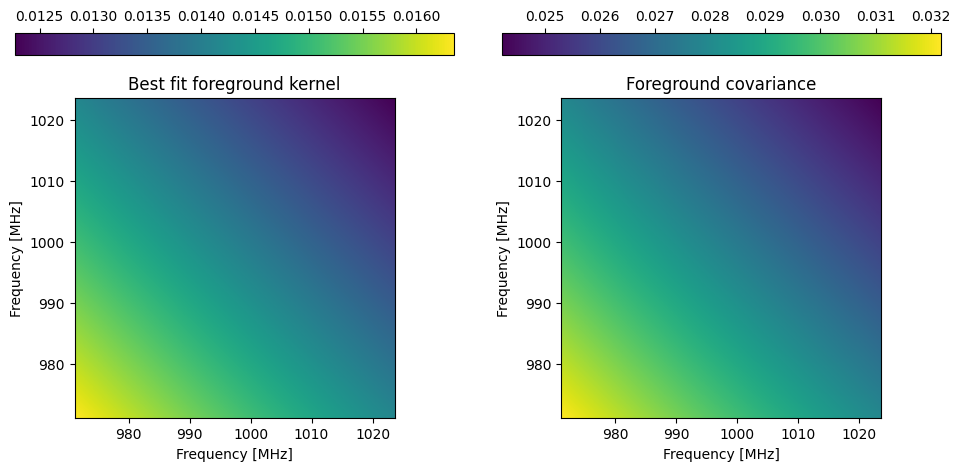

In [86]:
plot_HI_signal_kernal_comparison(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5)
plot_foreground_signal_kernal_comparison(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5, sp_indx_fg = True)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5, sp_indx_fg = True)

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/1d_power_spectrum_default_with_bounds1.pdf


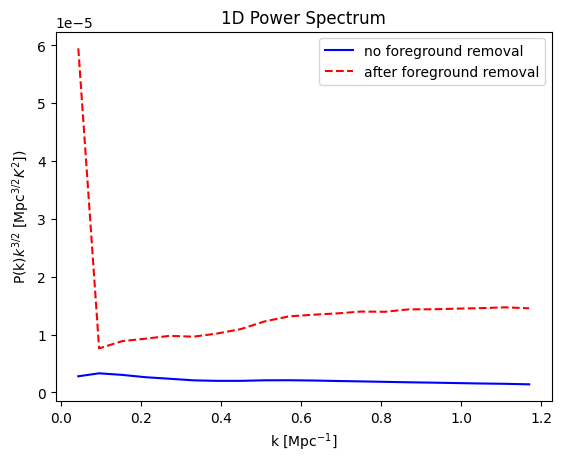

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/log_1d_power_spectrum_default_with_bounds1.pdf


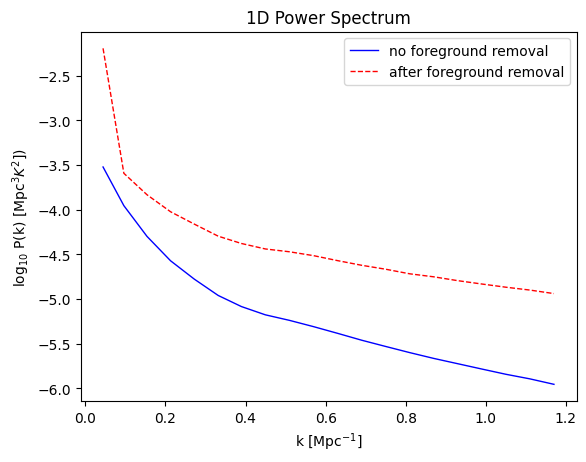

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_default_with_bounds1.pdf


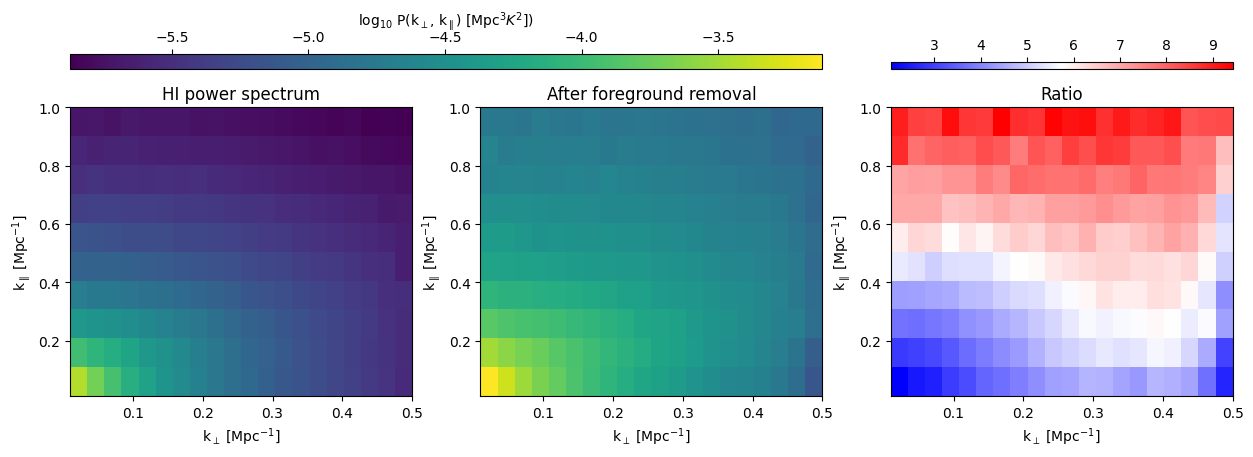

In [87]:
kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5, 
                                                            sp_indx_fg = True)

## Scipy optimise minimise 2

In [96]:
tot_map = hi_map + fg_map + noise_map
cov_tot, __, __, __ = pca_clean(tot_map, 4, weights = mock.w_HI, return_analysis = True, mean_center = True)

In [98]:
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
#x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = [
    (1e-6, 0.5),     # sigma_hi (exp)
    (1e-6, 0.5),        # sigma_fg (rbf)
    (1e-1, 5.0),       # l_hi (exp)
    (10.0, 1000.0),   # l_fg (rbf)
    (-5.0, -0.1),     # sp_indx_fg: physically must be negative
]

#best_fit = optimize.minimize(fun = function_to_optimise, x0 = x0, args = args, bounds = bounds) #method = 'Nelder-Mead',
    #options={'maxiter': 2000, 'maxfev': 5000}) #  method = 'Nelder-Mead'

best_fit = optimize.differential_evolution(func = function_to_optimise, x0 = x0, args = args, bounds = bounds) #method = 'Nelder-Mead',
    #options={'maxiter': 2000, 'maxfev': 5000}) #  method = 'Nelder-Mead'



In [99]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: Optimization terminated successfully.
Optimized Parameters: [ 1.30141091e-03  1.25679539e-01  1.00000000e-01  8.81539512e+02
 -2.35850642e+00]
Log-Marginial Likeligood: -1539.9271424260262


In [100]:
print(x0)
print(fitted_pars)

[ 1.90448375e-04  1.70609178e-01  1.00000000e+00  2.00000000e+01
 -2.70000000e+00]
[ 1.30141091e-03  1.25679539e-01  1.00000000e-01  8.81539512e+02
 -2.35850642e+00]


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/hi_signal_kernal_comparison_default_with_bounds1.pdf


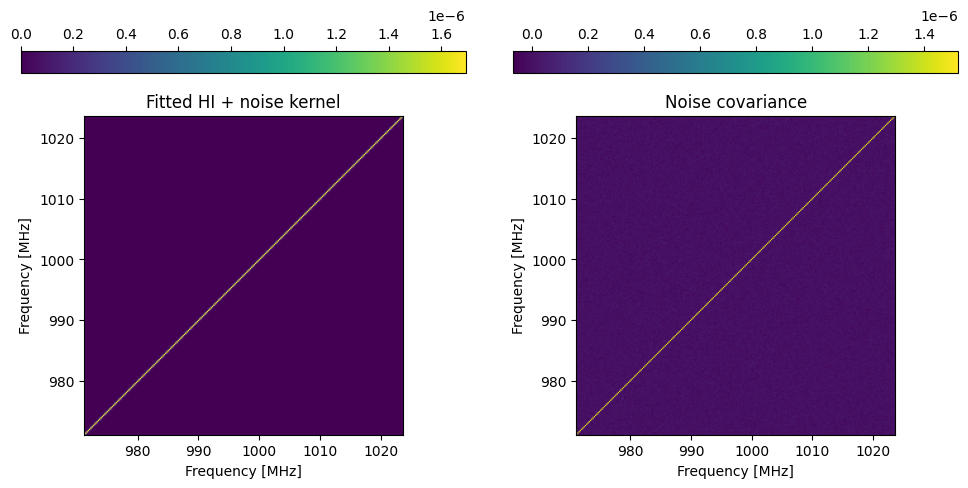

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/fg_signal_kernal_comparison_default_with_bounds1.pdf


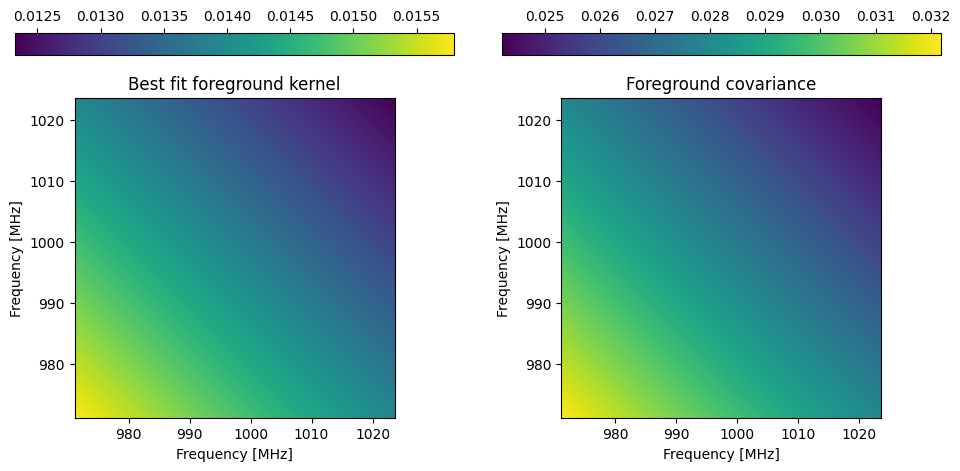

In [101]:
plot_HI_signal_kernal_comparison(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5)
plot_foreground_signal_kernal_comparison(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5, sp_indx_fg = True,
                                        kernel = rbf_kernel)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5, sp_indx_fg = True)

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/1d_power_spectrum_default_with_bounds1.pdf


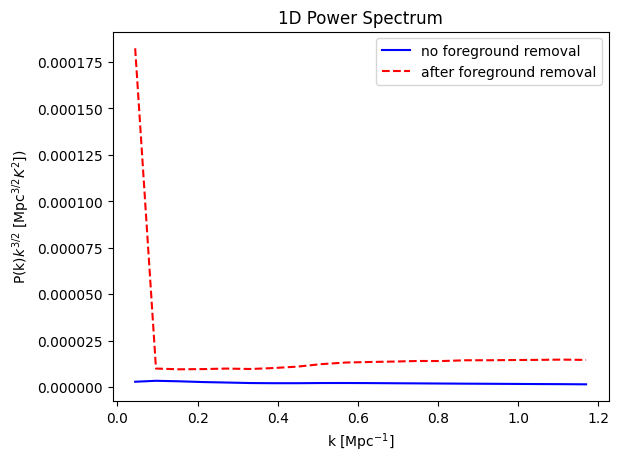

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/log_1d_power_spectrum_default_with_bounds1.pdf


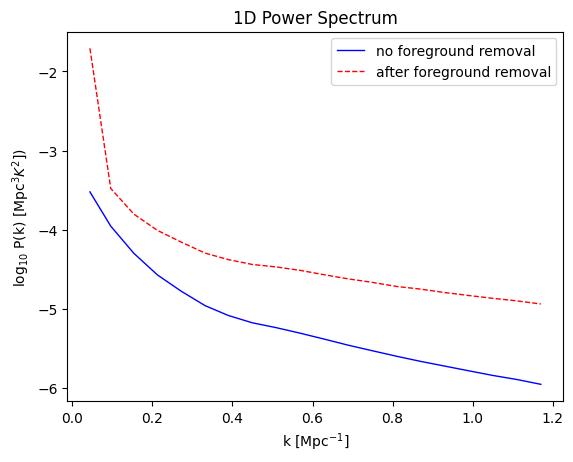

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_default_with_bounds1.pdf


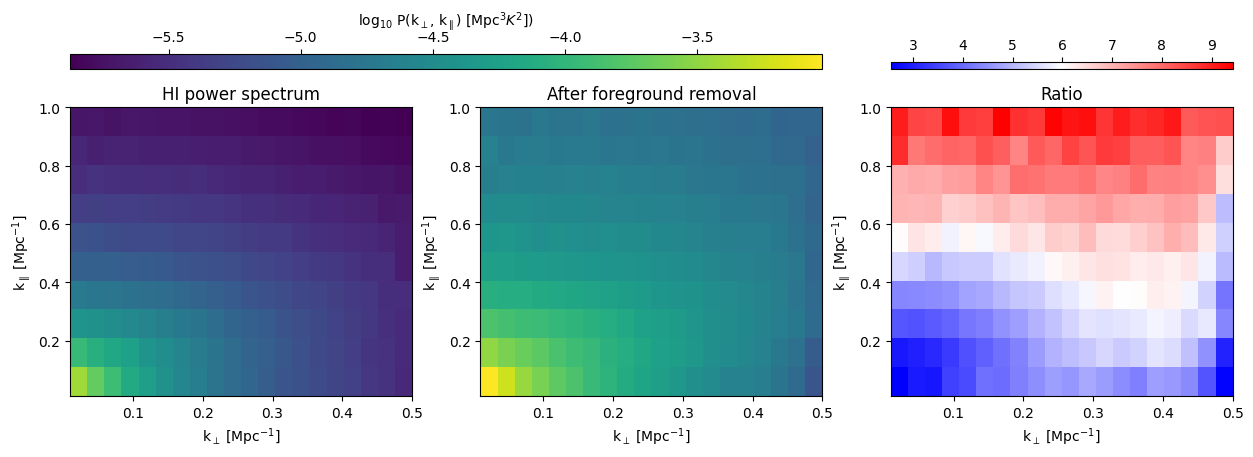

In [102]:
kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5, 
                                                            sp_indx_fg = True, kernel = rbf_kernel)

# New method

In [103]:
def fit_fg_only(params, xarr=None, cov_fg_approx=None, minimise=True):
    sigma_fg, l_fg, sp_indx_fg = params
    k_fg = rbf_kernel(xarr, xarr, sigma_fg, l_fg, sp_indx_fg)
    
    # Just match the foreground covariance structure
    residual = np.sum((cov_fg_approx - k_fg)**2)
    return residual


In [104]:
# Approximate foreground covariance by zeroing the diagonal of cov_tot
# (diagonal is dominated by HI + noise, off-diagonal by foreground)
cov_fg_approx = cov_tot.copy()
np.fill_diagonal(cov_fg_approx, 0)

x0_fg = np.array([0.17, 500.0, -2.7])
bounds_fg = [(1e-6, 0.5), (100.0, 5000.0), (-5.0, -0.1)]

In [106]:
# Subsample the covariance matrix to reduce computation
# Use every nth frequency channel instead of all 252
n = 4  # use every 4th channel → 63x63 matrix instead of 252x252
xarr_sub = (mock.nu / 1e6)[::n]
cov_fg_approx_sub = cov_fg_approx[::n, ::n]


In [107]:
result_fg = optimize.differential_evolution(
    func=fit_fg_only,
    args=(xarr_sub, cov_fg_approx_sub),
    bounds=bounds_fg,
    x0=x0_fg,
    seed=42,
    maxiter=2000,
    popsize=15,
    polish=True,
    workers=1,
    disp=True
)
sigma_fg_init, l_fg_init, sp_indx_fg_init = result_fg.x
print(f"Stage 1 — sigma_fg: {sigma_fg_init:.4f}, l_fg: {l_fg_init:.2f}, sp_indx_fg: {sp_indx_fg_init:.4f}")

differential_evolution step 1: f(x)= 0.05389835920090712
differential_evolution step 2: f(x)= 0.05389835920090712
differential_evolution step 3: f(x)= 0.05389835920090712
differential_evolution step 4: f(x)= 0.04983436589144184
differential_evolution step 5: f(x)= 0.04983436589144184
differential_evolution step 6: f(x)= 0.04962013042067338
differential_evolution step 7: f(x)= 0.04909724299385479
differential_evolution step 8: f(x)= 0.04902689301821876
differential_evolution step 9: f(x)= 0.04902689301821876
differential_evolution step 10: f(x)= 0.04902689301821876
differential_evolution step 11: f(x)= 0.04902689301821876
differential_evolution step 12: f(x)= 0.049011069151702696
differential_evolution step 13: f(x)= 0.04901075865330991
differential_evolution step 14: f(x)= 0.04901069435031838
Polishing solution with 'L-BFGS-B'
Stage 1 — sigma_fg: 0.1776, l_fg: 3231.42, sp_indx_fg: -2.6195


In [108]:
x0_joint = np.array([
    1.29e-03,        # sigma_hi
    sigma_fg_init,   # from stage 1
    0.08,            # l_hi
    l_fg_init,       # from stage 1
    sp_indx_fg_init  # from stage 1
], dtype=float)

In [109]:

bounds_joint = [
    (1e-6, 0.005),
    (1e-6, 0.5),
    (0.01, 0.5),
    (100.0, 5000.0),
    (-5.0, -0.1)
]

In [111]:
n = 4
xarr_sub   = (mock.nu / 1e6)[::n]
cov_tot_sub = cov_tot[::n, ::n]

best_fit = optimize.differential_evolution(
    func=function_to_optimise,
    x0=x0_joint,
    args=(xarr_sub, cov_tot_sub),   # subsampled
    bounds=bounds_joint,
    tol=1e-6,
    seed=42,
    maxiter=2000,
    popsize=15,
    polish=True,
    workers=1,
    disp=True
)

differential_evolution step 1: f(x)= -379.3621833180994
differential_evolution step 2: f(x)= -379.3621833180994
differential_evolution step 3: f(x)= -379.3621833180994
differential_evolution step 4: f(x)= -379.3621833180994
differential_evolution step 5: f(x)= -379.72174313117085
differential_evolution step 6: f(x)= -379.72174313117085
differential_evolution step 7: f(x)= -379.75113502521253
differential_evolution step 8: f(x)= -379.75113502521253
differential_evolution step 9: f(x)= -379.81962375673754
differential_evolution step 10: f(x)= -379.81962375673754
differential_evolution step 11: f(x)= -379.81962375673754
differential_evolution step 12: f(x)= -379.87356131061364
differential_evolution step 13: f(x)= -379.87356131061364
differential_evolution step 14: f(x)= -379.87356131061364
differential_evolution step 15: f(x)= -379.8909467196257
differential_evolution step 16: f(x)= -379.89316155297763
differential_evolution step 17: f(x)= -379.89316155297763
differential_evolution step 

In [113]:
print(f"Success: {best_fit.success}")
print(f"LML: {-best_fit.fun:.4f}")
for name, val in zip(["sigma_hi", "sigma_fg", "l_hi", "l_fg", "sp_indx_fg"], best_fit.x):
    print(f"  {name:12s}: {val:.6f}")

fitted_pars = best_fit.x

Success: True
LML: 379.9029
  sigma_hi    : 0.001294
  sigma_fg    : 0.136873
  l_hi        : 0.215068
  l_fg        : 4999.360982
  sp_indx_fg  : -2.700648


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/hi_signal_kernal_comparison_default_with_bounds1.pdf


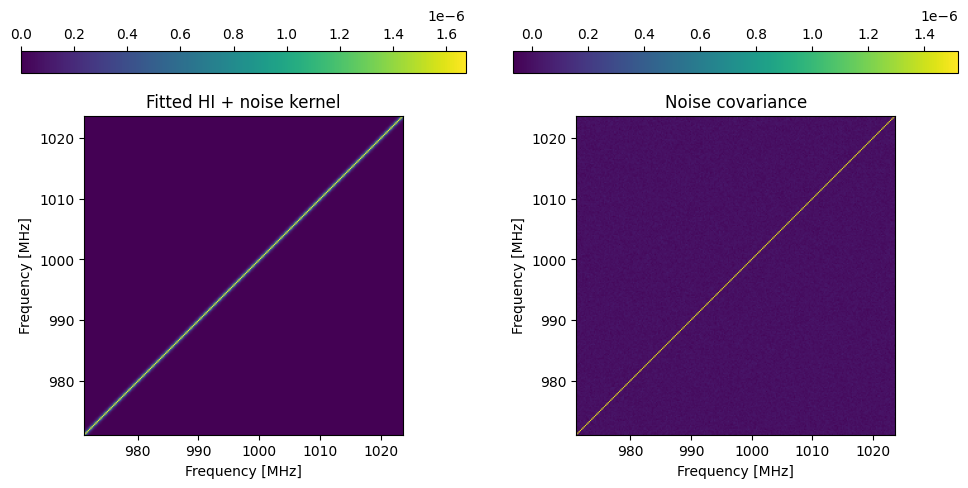

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/fg_signal_kernal_comparison_default_with_bounds1.pdf


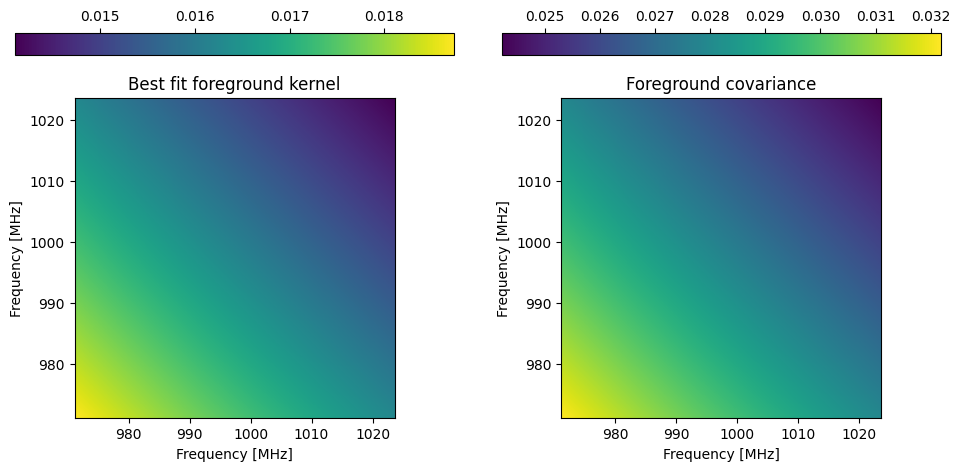

In [114]:
plot_HI_signal_kernal_comparison(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5)
plot_foreground_signal_kernal_comparison(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5, sp_indx_fg = True,
                                        kernel = rbf_kernel)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5, sp_indx_fg = True)

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/1d_power_spectrum_default_with_bounds1.pdf


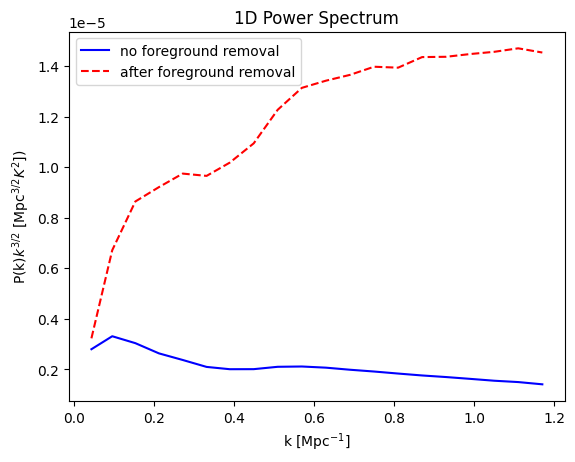

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/log_1d_power_spectrum_default_with_bounds1.pdf


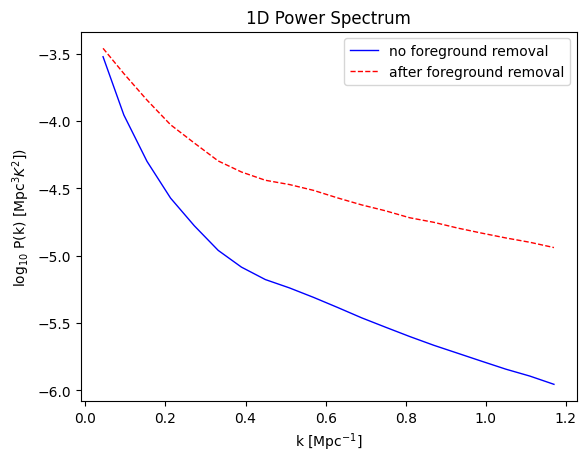

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_default_with_bounds1.pdf


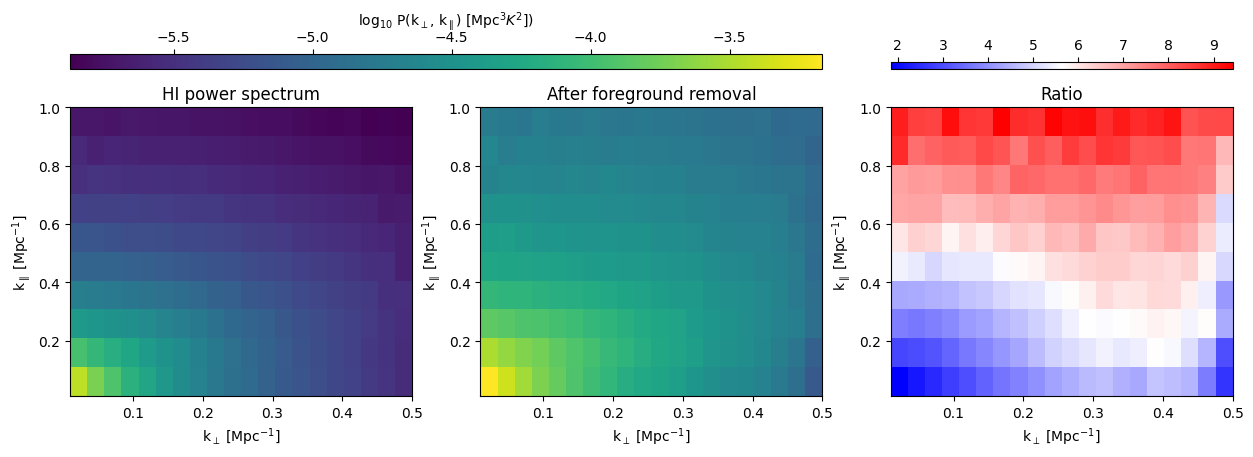

In [115]:
kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5, 
                                                            sp_indx_fg = True, kernel = rbf_kernel)

## Differential evolution

In [317]:
tot_map = hi_map + fg_map + noise_map
cov_tot, __, __, __ = pca_clean(tot_map, 0, weights = mock.w_HI, return_analysis = True, mean_center = True)

In [318]:
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = [
    (1e-6, 0.5),     # sigma_hi (exp)
    (1e-6, 0.5),        # sigma_fg (rbf)
    (1e-1, 5.0),       # l_hi (exp)
    (10.0, 1000.0),   # l_fg (rbf)
    (-5.0, -0.1),     # sp_indx_fg: physically must be negative
]
best_fit = optimize.differential_evolution(func = function_to_optimise, x0 = x0, args = args, bounds = bounds,
                                          tol = 1e-6, seed = 42, maxiter = 1000, workers = -1)

KeyboardInterrupt: 

In [ ]:
print(x0)
print(best_fit.x)

In [ ]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

In [ ]:
plot_HI_signal_kernal_comparison(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5)
plot_foreground_signal_kernal_comparison(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5, sp_indx_fg = True)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5, sp_indx_fg = True)

In [ ]:
kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5, 
                                                            sp_indx_fg = True)

## MCMC

In [202]:
import emcee

### no spectral index

In [235]:
def log_prior(params):
    sigma_hi, sigma_fg, l_hi, l_fg = params
    if (1e-6 < sigma_hi < 0.5 and
        1e-6 < sigma_fg < 0.5 and
        0.01  < l_hi    < 2.0 and
        10.0  < l_fg    < 1000.0):
        return 0.0          # flat prior within bounds
    return -np.inf

In [236]:
def log_posterior(params, xarr, cov_tot):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    ll = function_to_optimise_no_sp_indx(
        params, xarr=xarr, cov_tot=cov_tot, minimise=False
    )
    return lp + ll if np.isfinite(ll) else -np.inf

In [237]:
# initialise walkers near the best guess x0
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg], dtype=float)
#x0 = fitted_pars # from differential evolution

ndim     = len(x0)
nwalkers = 32                          # must be even and >= 2*ndim
nsteps   = 5000
nburn    = 500

# Small Gaussian ball around x0; nudge each walker by ~1 %
rng      = np.random.default_rng(42)
p0       = x0[None, :] + 1e-3 * rng.standard_normal((nwalkers, ndim)) * x0[None, :]

In [238]:
# run the sampler
xarr    = mock.nu / 1e6          # shape consistent with your functions
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior,
    args=(xarr, cov_tot)
)

print("Burning in …")
state = sampler.run_mcmc(p0, nburn, progress=True)
sampler.reset()

print("Sampling …")
sampler.run_mcmc(state, nsteps, progress=True)

Burning in …


100%|█████████████████████████████████████████| 500/500 [01:40<00:00,  4.96it/s]


Sampling …


100%|███████████████████████████████████████| 5000/5000 [15:34<00:00,  5.35it/s]


State([[1.27569854e-03 2.68246681e-01 2.97450002e-02 4.96644944e+02]
 [1.28163328e-03 4.85060437e-01 1.44535387e-02 5.11649249e+02]
 [1.30972841e-03 4.34386967e-01 8.88315202e-02 6.36925732e+02]
 [1.29778161e-03 2.25074466e-01 9.54670544e-02 3.81849909e+02]
 [1.26301910e-03 4.94342114e-01 1.10892938e-01 6.24729249e+02]
 [1.39188388e-03 4.58889213e-01 1.04058897e-01 7.56069588e+02]
 [1.27438654e-03 9.04133760e-02 1.22265174e-01 1.31215019e+02]
 [1.38100618e-03 2.48301803e-01 7.86189412e-02 7.10313299e+02]
 [1.22776198e-03 2.96784495e-01 8.25650786e-02 3.33121057e+02]
 [1.28466814e-03 1.85613847e-01 9.82695397e-02 9.06512173e+02]
 [1.27979014e-03 4.44103015e-01 7.59864943e-02 7.06492387e+02]
 [1.27067120e-03 2.20506128e-01 7.48211757e-02 3.97093827e+02]
 [1.32839312e-03 4.43141189e-01 5.42200634e-02 8.22759415e+02]
 [1.32625826e-03 2.19770600e-01 1.00132538e-01 8.67424951e+02]
 [1.28628006e-03 4.98477667e-01 3.26905677e-02 7.40650698e+02]
 [1.30230779e-03 3.87086736e-01 2.65231590e-02 8.

In [243]:
# diagnostic
tau   = sampler.get_autocorr_time(quiet=True)
print(f"Autocorrelation times: {tau}")
print(f"Recommended burn-in  : {int(2 * tau.max())} steps")

# Flatten chain (thin by half the min autocorr time to reduce correlation)
thin    = max(1, int(tau.min() / 2))
samples = sampler.get_chain(flat=True, thin=thin)   # shape (N, ndim)
log_prob_samples = sampler.get_log_prob(flat=True, thin=thin)

param_names = ["sigma_hi", "sigma_fg", "l_hi", "l_fg"]

Autocorrelation times: [54.64910565 57.67644376 58.18211278 63.98772666]
Recommended burn-in  : 127 steps


In [244]:
# results
medians = np.median(samples, axis=0)
stds    = np.std(samples,    axis=0)
for name, med, std in zip(param_names, medians, stds):
    print(f"  {name:12s}: {med:.4f} ± {std:.4f}")

# Best-fit (MAP) parameters
best_idx    = np.argmax(log_prob_samples)
best_params = samples[best_idx]
map_params_without = samples[best_idx]
print("\nMAP params:", best_params)

  sigma_hi    : 0.0013 ± 0.0001
  sigma_fg    : 0.3111 ± 0.1043
  l_hi        : 0.0748 ± 0.0313
  l_fg        : 542.6739 ± 213.2931

MAP params: [1.30074015e-03 2.38240160e-01 8.43079587e-02 4.50199535e+02]


In [257]:
# Extract samples
tau = sampler.get_autocorr_time(quiet=True)
thin = max(1, int(tau.min() / 2))
samples = sampler.get_chain(flat=True, thin=thin)
log_prob_samples = sampler.get_log_prob(flat=True, thin=thin)

best_idx = np.argmax(log_prob_samples)
best_params = samples[best_idx]

# Save immediately
np.save('mcmc_samples_without_sp_indx.npy', samples)
np.save('mcmc_log_probs_without_sp_indx.npy', log_prob_samples)
np.save('mcmc_map_params_without_sp_indx.npy', best_params)
print("Saved!")

Saved!


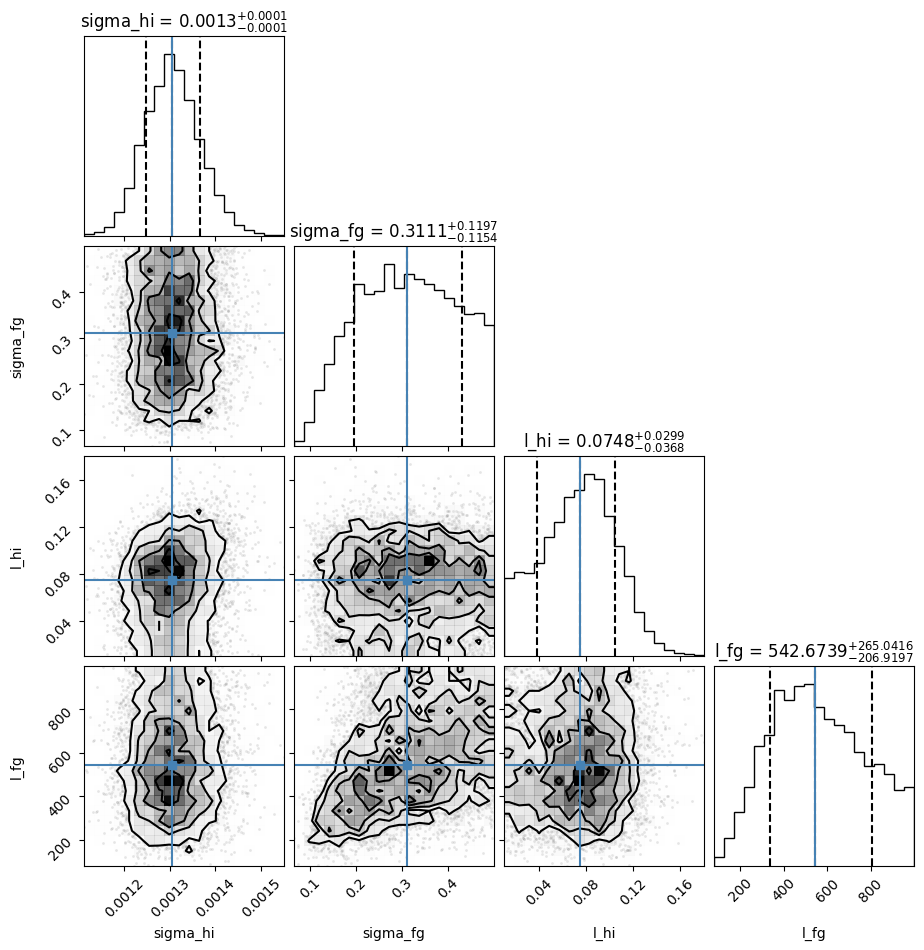

In [245]:
# corner plot
try:
    import corner
    fig = corner.corner(samples, labels=param_names, truths=medians,
                    quantiles=[0.16, 0.5, 0.84], show_titles=True,
                    title_fmt=".4f")
    fig.savefig("mcmc_corner.png", dpi=150, bbox_inches="tight")
    plt.show()
except ImportError:
    print("pip install corner to get the corner plot")

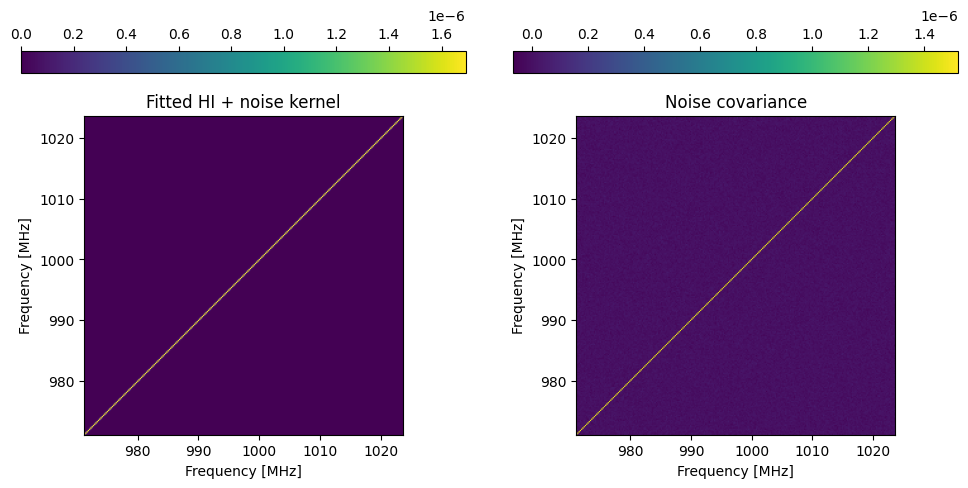

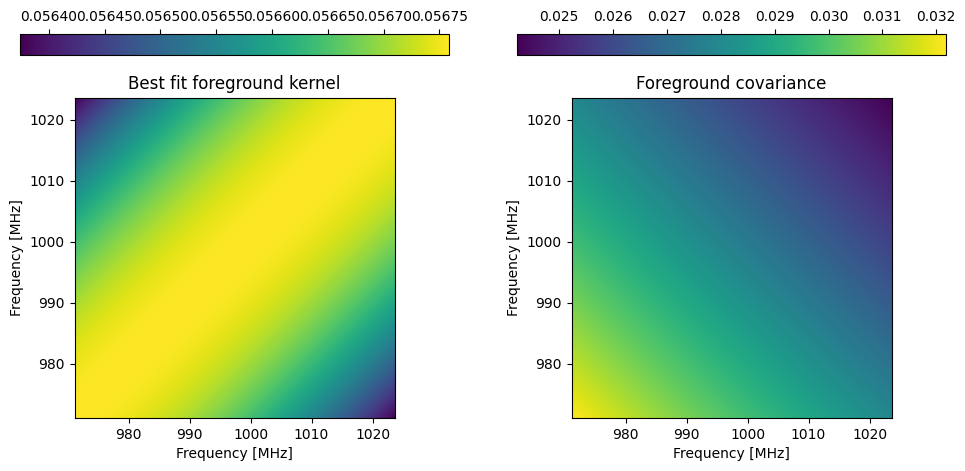

In [248]:
plot_HI_signal_kernal_comparison(best_params, method = "default_with_bounds1", save_plot = False, week_number = 5)
plot_foreground_signal_kernal_comparison(best_params, method = "default_with_bounds1", save_plot = False, week_number = 5, sp_indx_fg = False)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5, sp_indx_fg = True)

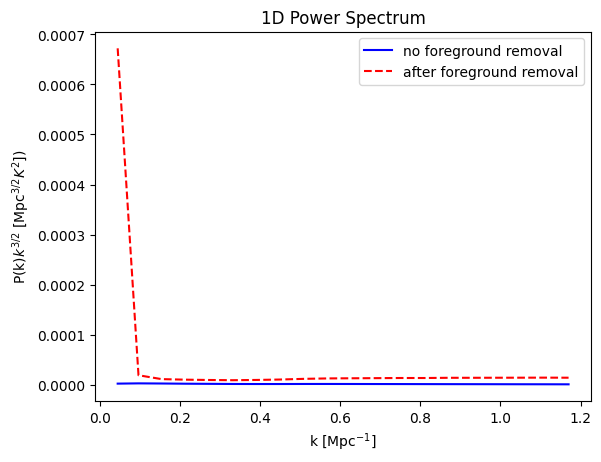

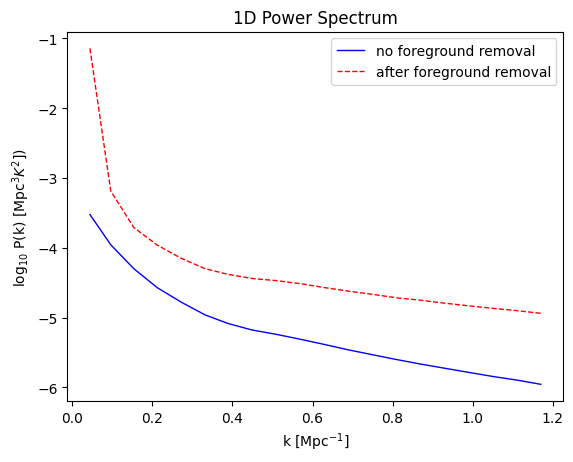

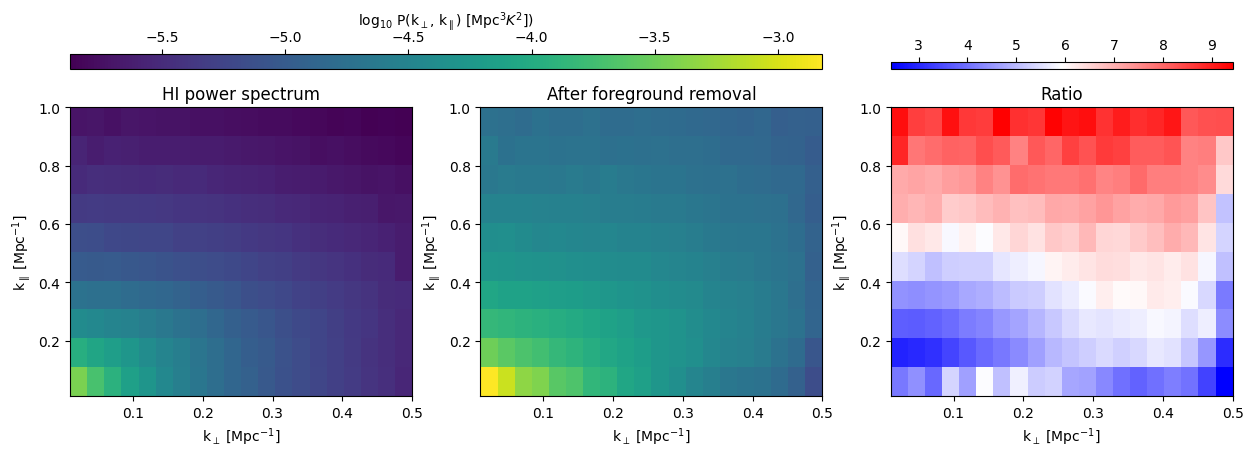

In [249]:
kernal_foreground_removal_1d_and_cylindrical_power_spectrum(best_params, method = "default_with_bounds1", save_plot = False, week_number = 5, 
                                                            sp_indx_fg = False)

### spectral index 1

In [ ]:
def log_prior(params):
    sigma_hi, sigma_fg, l_hi, l_fg, sp_indx_fg = params
    if (1e-6  < sigma_hi   < 0.5   and
        1e-6  < sigma_fg   < 0.5   and
        0.01  < l_hi       < 2.0   and
        10.0  < l_fg       < 1000.0 and
        -5.0  < sp_indx_fg < -1.0):
        return 0.0
    return -np.inf

In [204]:
def log_posterior(params, xarr, cov_tot):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    ll = function_to_optimise(
        params, xarr=xarr, cov_tot=cov_tot, minimise=False
    )
    return lp + ll if np.isfinite(ll) else -np.inf

In [205]:
# initialise walkers near the best guess x0
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype=float)
x0 = fitted_pars # from differential evolution

ndim     = len(x0)   # now 5
nwalkers = 40        # bumped up slightly for the extra dimension
nburn    = 500
nsteps   = 5000

rng = np.random.default_rng(42)
p0  = x0[None, :] + 1e-3 * rng.standard_normal((nwalkers, ndim)) * x0[None, :]

In [ ]:
# run the sampler
xarr    = mock.nu / 1e6
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior,
    args=(xarr, cov_tot)
)

print("Burning in …")
state = sampler.run_mcmc(p0, nburn, progress=True)
sampler.reset()

print("Sampling …")
sampler.run_mcmc(state, nsteps, progress=True)

In [179]:
# diagnostics
tau = sampler.get_autocorr_time(quiet=True)
print(f"Autocorrelation times: {tau}")

thin    = max(1, int(tau.min() / 2))
samples = sampler.get_chain(flat=True, thin=thin)
log_prob_samples = sampler.get_log_prob(flat=True, thin=thin)

param_names = ["sigma_hi", "sigma_fg", "l_hi", "l_fg", "sp_indx_fg"]

Autocorrelation times: [69.80967733 71.80047972 83.54989296 78.98957433 76.14687975]


In [256]:
# Extract samples
tau = sampler.get_autocorr_time(quiet=True)
thin = max(1, int(tau.min() / 2))
samples = sampler.get_chain(flat=True, thin=thin)
log_prob_samples = sampler.get_log_prob(flat=True, thin=thin)

best_idx = np.argmax(log_prob_samples)
best_params = samples[best_idx]

# Save immediately
np.save('mcmc_samples_with_sp_indx1.npy', samples)
np.save('mcmc_log_probs_with_sp_indx1.npy', log_prob_samples)
np.save('mcmc_map_params_with_sp_indx1.npy', best_params)
print("Saved!")

Saved!


In [177]:
# results
medians = np.median(samples, axis=0)
stds    = np.std(samples,    axis=0)
for name, med, std in zip(param_names, medians, stds):
    print(f"  {name:12s}: {med:.4f} ± {std:.4f}")

best_idx    = np.argmax(log_prob_samples)
best_params = samples[best_idx]
print("\nMAP params:", dict(zip(param_names, best_params)))

  sigma_hi    : 0.0013 ± 0.0001
  sigma_fg    : 0.2247 ± 0.1096
  l_hi        : 0.0745 ± 0.0310
  l_fg        : 741.8189 ± 192.7753
  sp_indx_fg  : -2.9197 ± 0.9810

MAP params: {'sigma_hi': 0.0012930636579518374, 'sigma_fg': 0.1401893396089554, 'l_hi': 0.08085085209469475, 'l_fg': 938.2952369331067, 'sp_indx_fg': -2.6927778461524396}


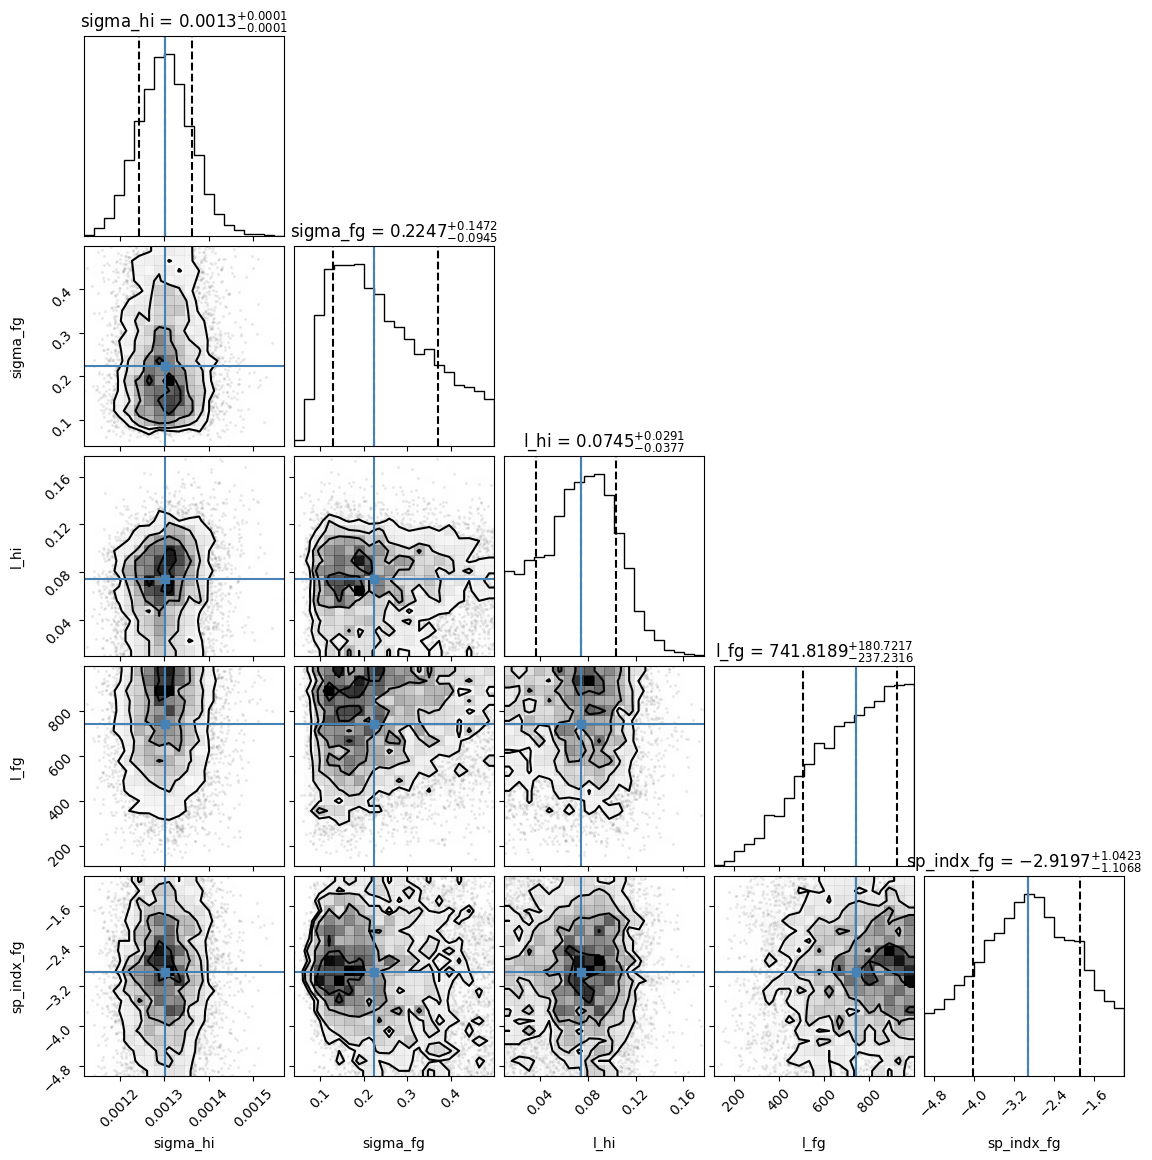

In [181]:
# corner plot
try:
    import corner
    fig = corner.corner(samples, labels=param_names, truths=medians,
                    quantiles=[0.16, 0.5, 0.84], show_titles=True,
                    title_fmt=".4f")
    fig.savefig("mcmc_corner.png", dpi=150, bbox_inches="tight")
    plt.show()
except ImportError:
    print("pip install corner to get the corner plot")

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/hi_signal_kernal_comparison_default_with_bounds1.pdf


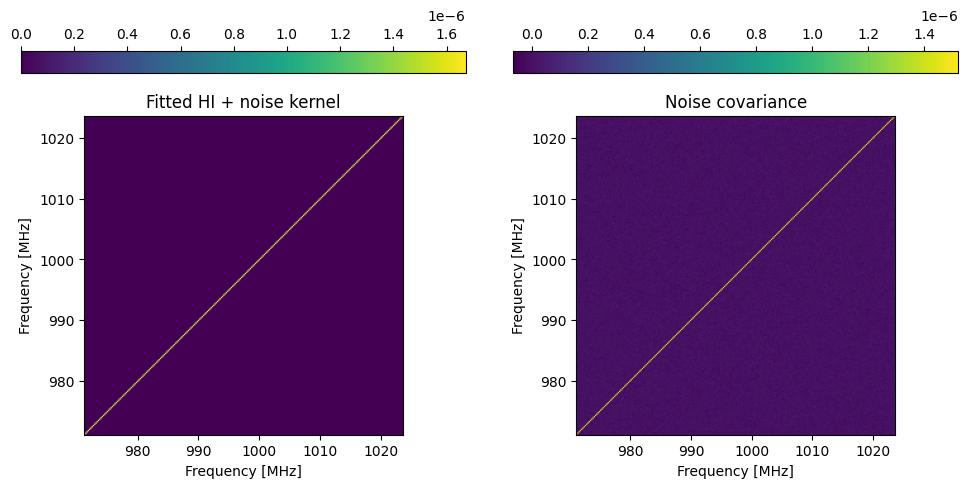

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/fg_signal_kernal_comparison_default_with_bounds1.pdf


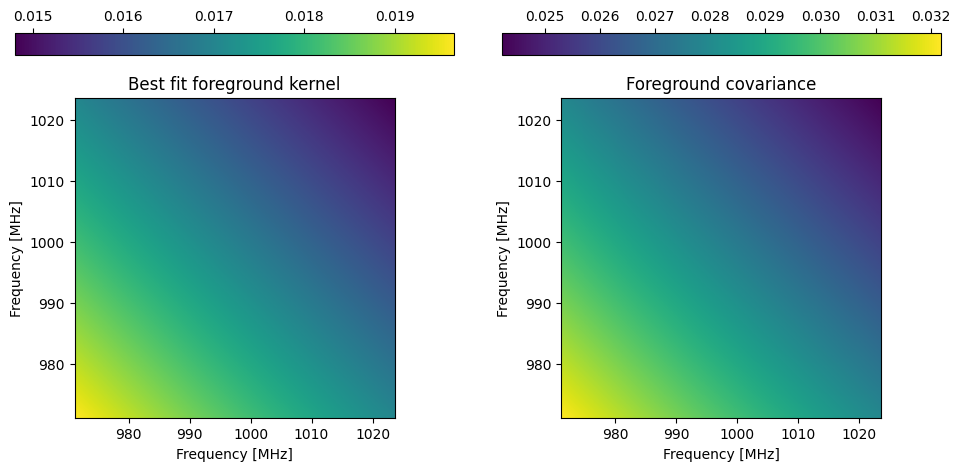

In [206]:
plot_HI_signal_kernal_comparison(best_params, method = "default_with_bounds1", save_plot = True, week_number = 5)
plot_foreground_signal_kernal_comparison(best_params, method = "default_with_bounds1", save_plot = True, week_number = 5, sp_indx_fg = True)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5, sp_indx_fg = True)

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/1d_power_spectrum_default_with_bounds1.pdf


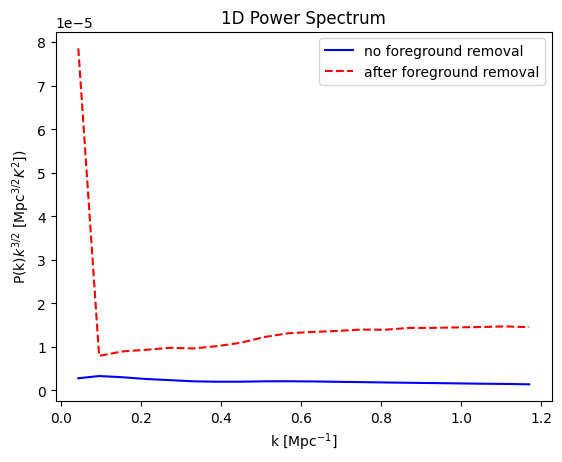

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/log_1d_power_spectrum_default_with_bounds1.pdf


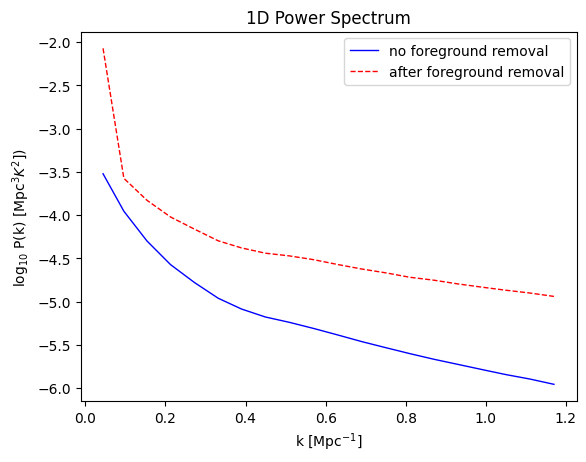

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_default_with_bounds1.pdf


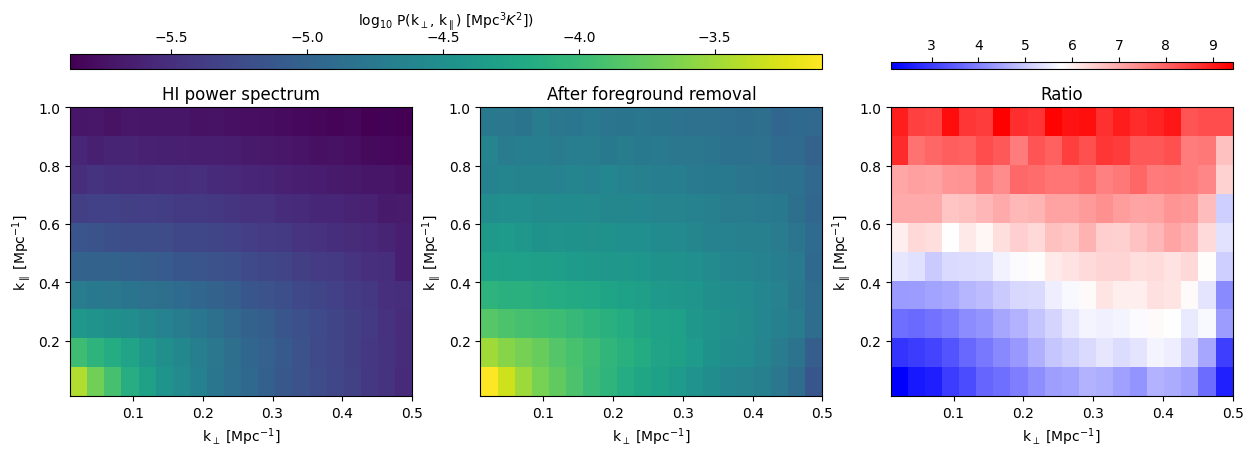

In [207]:
kernal_foreground_removal_1d_and_cylindrical_power_spectrum(best_params, method = "default_with_bounds1", save_plot = True, week_number = 5, 
                                                            sp_indx_fg = True)

### spectral index 2

In [208]:
def log_prior(params):
    sigma_hi, sigma_fg, l_hi, l_fg, sp_indx_fg = params
    if (1e-6  < sigma_hi   < 0.5   and
        1e-6  < sigma_fg   < 1.0   and # was previously hitting upper bound of 0.5
        0.01  < l_hi       < 2.0   and
        10.0  < l_fg       < 2000.0 and # was previously hitting upper bound of 1000
        -5.0  < sp_indx_fg < -1.0):
        return 0.0
    return -np.inf

In [209]:
# initialise walkers near the best guess x0
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype=float)
x0 = fitted_pars # from differential evolution

ndim     = len(x0)   # now 5
nwalkers = 40        # bumped up slightly for the extra dimension
nburn    = 500
nsteps   = 5000

rng = np.random.default_rng(42)
p0  = x0[None, :] + 1e-3 * rng.standard_normal((nwalkers, ndim)) * x0[None, :]

In [210]:
# run the sampler
xarr    = mock.nu / 1e6
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior,
    args=(xarr, cov_tot)
)

print("Burning in …")
state = sampler.run_mcmc(p0, nburn, progress=True)
sampler.reset()

print("Sampling …")
sampler.run_mcmc(state, nsteps, progress=True)

Burning in …


100%|█████████████████████████████████████████| 500/500 [02:10<00:00,  3.82it/s]


Sampling …


100%|███████████████████████████████████████| 5000/5000 [19:19<00:00,  4.31it/s]


State([[ 1.29055758e-03  2.57531704e-01  8.59149468e-02  1.46015367e+03
  -3.90928055e+00]
 [ 1.38956729e-03  5.02630065e-01  1.01848670e-01  1.21794614e+03
  -1.81455919e+00]
 [ 1.25199589e-03  1.50213812e-01  4.55529479e-02  7.21311488e+02
  -2.64731215e+00]
 [ 1.19624213e-03  4.10640623e-01  3.54198184e-02  8.44564418e+02
  -1.62962611e+00]
 [ 1.31138350e-03  5.54589093e-01  9.66231706e-02  1.79919061e+03
  -3.76862068e+00]
 [ 1.22340378e-03  5.47132299e-01  7.66950865e-02  1.87638826e+03
  -1.83485665e+00]
 [ 1.29649030e-03  1.58291571e-01  7.24704156e-02  1.30956866e+03
  -4.45911353e+00]
 [ 1.33294629e-03  2.09443284e-01  3.46694128e-02  1.52941533e+03
  -2.69207469e+00]
 [ 1.34690347e-03  4.10743091e-01  6.84175157e-02  6.50333424e+02
  -4.72006116e+00]
 [ 1.35477899e-03  2.77048858e-01  5.68463475e-02  1.51683571e+03
  -4.60422294e+00]
 [ 1.36280262e-03  1.08932966e-01  1.18060732e-01  1.58157367e+03
  -2.76073357e+00]
 [ 1.38503079e-03  2.12189582e-01  1.10273256e-01  1.211295

In [258]:
# Recovered from printed state
final_positions = np.array([
    [ 1.29055758e-03,  2.57531704e-01,  8.59149468e-02,  1.46015367e+03, -3.90928055e+00],
    [ 1.38956729e-03,  5.02630065e-01,  1.01848670e-01,  1.21794614e+03, -1.81455919e+00],
    [ 1.25199589e-03,  1.50213812e-01,  4.55529479e-02,  7.21311488e+02, -2.64731215e+00],
    [ 1.19624213e-03,  4.10640623e-01,  3.54198184e-02,  8.44564418e+02, -1.62962611e+00],
    [ 1.31138350e-03,  5.54589093e-01,  9.66231706e-02,  1.79919061e+03, -3.76862068e+00],
    [ 1.22340378e-03,  5.47132299e-01,  7.66950865e-02,  1.87638826e+03, -1.83485665e+00],
    [ 1.29649030e-03,  1.58291571e-01,  7.24704156e-02,  1.30956866e+03, -4.45911353e+00],
    [ 1.33294629e-03,  2.09443284e-01,  3.46694128e-02,  1.52941533e+03, -2.69207469e+00],
    [ 1.34690347e-03,  4.10743091e-01,  6.84175157e-02,  6.50333424e+02, -4.72006116e+00],
    [ 1.35477899e-03,  2.77048858e-01,  5.68463475e-02,  1.51683571e+03, -4.60422294e+00],
    [ 1.36280262e-03,  1.08932966e-01,  1.18060732e-01,  1.58157367e+03, -2.76073357e+00],
    [ 1.38503079e-03,  2.12189582e-01,  1.10273256e-01,  1.21129588e+03, -3.31591022e+00],
    [ 1.35523366e-03,  1.22461237e-01,  1.15620477e-01,  8.53817738e+02, -3.77538647e+00],
    [ 1.39111015e-03,  3.00862598e-01,  7.38253272e-02,  1.63746867e+03, -1.32974062e+00],
    [ 1.42396704e-03,  2.05915869e-01,  1.36424591e-01,  1.32269189e+03, -2.69236346e+00],
    [ 1.30472488e-03,  3.43003035e-01,  2.74091262e-02,  1.56099222e+03, -1.22452826e+00],
    [ 1.29373690e-03,  5.04424431e-01,  9.49875453e-02,  1.75812393e+03, -3.09702456e+00],
    [ 1.25178059e-03,  3.78592960e-01,  4.78979145e-02,  1.76414200e+03, -2.25626067e+00],
    [ 1.29728563e-03,  6.55234310e-01,  8.92061600e-02,  1.75062455e+03, -1.22929897e+00],
    [ 1.39613936e-03,  1.92927710e-01,  1.74195416e-01,  1.63987664e+03, -2.03098633e+00],
    [ 1.22560137e-03,  2.42549741e-01,  7.74176871e-02,  1.56592959e+03, -1.87456032e+00],
    [ 1.27909061e-03,  5.61894898e-01,  1.11767552e-01,  1.71990802e+03, -4.13575176e+00],
    [ 1.32024839e-03,  2.85774880e-01,  1.06716072e-01,  1.97570160e+03, -1.89960470e+00],
    [ 1.28700423e-03,  3.66217963e-01,  5.71931881e-02,  1.87355613e+03, -4.01950297e+00],
    [ 1.36595834e-03,  2.74215277e-01,  2.31359885e-02,  1.24279940e+03, -3.48975876e+00],
    [ 1.30633566e-03,  5.10987849e-01,  8.38171431e-02,  1.57378237e+03, -1.16156259e+00],
    [ 1.32692792e-03,  7.61064006e-01,  1.09753545e-01,  8.47910905e+02, -2.93114558e+00],
    [ 1.39277634e-03,  1.27431900e-01,  1.05364789e-01,  6.32798610e+02, -2.84705316e+00],
    [ 1.34158917e-03,  2.29671929e-01,  9.57637887e-02,  1.66315319e+03, -2.12702626e+00],
    [ 1.37317507e-03,  6.48103684e-01,  1.03225535e-01,  1.50938166e+03, -1.50244095e+00],
    [ 1.32220258e-03,  1.47842502e-01,  1.07393962e-01,  1.56534742e+03, -3.01885742e+00],
    [ 1.25599940e-03,  6.79504121e-01,  1.07361965e-01,  1.61831001e+03, -3.05571546e+00],
    [ 1.32254923e-03,  3.00511119e-01,  8.55051238e-02,  1.72251790e+03, -1.66648255e+00],
    [ 1.34349706e-03,  3.03585403e-01,  1.57048529e-02,  1.24391058e+03, -2.87871747e+00],
    [ 1.31486705e-03,  1.92549107e-01,  2.28511581e-02,  3.23835512e+02, -3.01965971e+00],
    [ 1.31608993e-03,  4.51494406e-01,  3.26913883e-02,  1.66171154e+03, -4.11658421e+00],
    [ 1.31528273e-03,  1.71084970e-01,  8.61538992e-02,  1.51572842e+03, -3.04821182e+00],
    [ 1.26978820e-03,  1.68681772e-01,  6.71031836e-02,  9.01783444e+02, -4.06074592e+00],
    [ 1.27997493e-03,  1.76428496e-01,  7.81925020e-02,  1.56143885e+03, -2.36867183e+00],
    [ 1.31951729e-03,  4.56032097e-01,  9.29881320e-02,  6.31871539e+02, -1.51679468e+00],
])

log_probs = np.array([1539.39939661, 1537.32233532, 1539.23773011, 1536.38435952,
                      1538.70266913, 1538.07174032, 1536.79824869, 1539.58261307,
                      1537.70198467, 1537.25541462, 1539.47785131, 1538.64875304,
                      1538.13651808, 1537.56400066, 1537.03381506, 1537.92290536,
                      1539.05771645, 1538.8591538,  1538.08242784, 1534.09983289,
                      1539.04214718, 1537.83284114, 1539.22834326, 1538.78307375,
                      1538.27012046, 1538.30458268, 1536.80454651, 1538.44990192,
                      1539.74549523, 1537.23334697, 1540.12208765, 1537.64916174,
                      1539.27981642, 1538.66292946, 1537.58747146, 1538.14572499,
                      1540.50716324, 1539.08559093, 1540.53435977, 1537.73823365])

# MAP params are the walker with the highest log prob
best_idx = np.argmax(log_probs)
map_params_with = final_positions[best_idx]
print(f"MAP params: {dict(zip(param_names, map_params_with))}")

MAP params: {'sigma_hi': 0.00127997493, 'sigma_fg': 0.176428496, 'l_hi': 0.078192502, 'l_fg': 1561.43885, 'sp_indx_fg': -2.36867183}


In [253]:
# diagnostics
tau = sampler.get_autocorr_time(quiet=True)
print(f"Autocorrelation times: {tau}")

thin    = max(1, int(tau.min() / 2))
samples = sampler.get_chain(flat=True, thin=thin)
log_prob_samples = sampler.get_log_prob(flat=True, thin=thin)

param_names = ["sigma_hi", "sigma_fg", "l_hi", "l_fg", "sp_indx_fg"]

Autocorrelation times: [54.64910565 57.67644376 58.18211278 63.98772666]


In [251]:
# results
medians = np.median(samples, axis=0)
stds    = np.std(samples,    axis=0)
for name, med, std in zip(param_names, medians, stds):
    print(f"  {name:12s}: {med:.4f} ± {std:.4f}")

best_idx    = np.argmax(log_prob_samples)
best_params = samples[best_idx]
map_params_with = samples[best_idx]
print("\nMAP params:", dict(zip(param_names, best_params)))

  sigma_hi    : 0.0013 ± 0.0001
  sigma_fg    : 0.3111 ± 0.1043
  l_hi        : 0.0748 ± 0.0313
  l_fg        : 542.6739 ± 213.2931

MAP params: {'sigma_hi': 0.0013007401469109596, 'sigma_fg': 0.23824015986520147, 'l_hi': 0.0843079586775577, 'l_fg': 450.1995350396561}


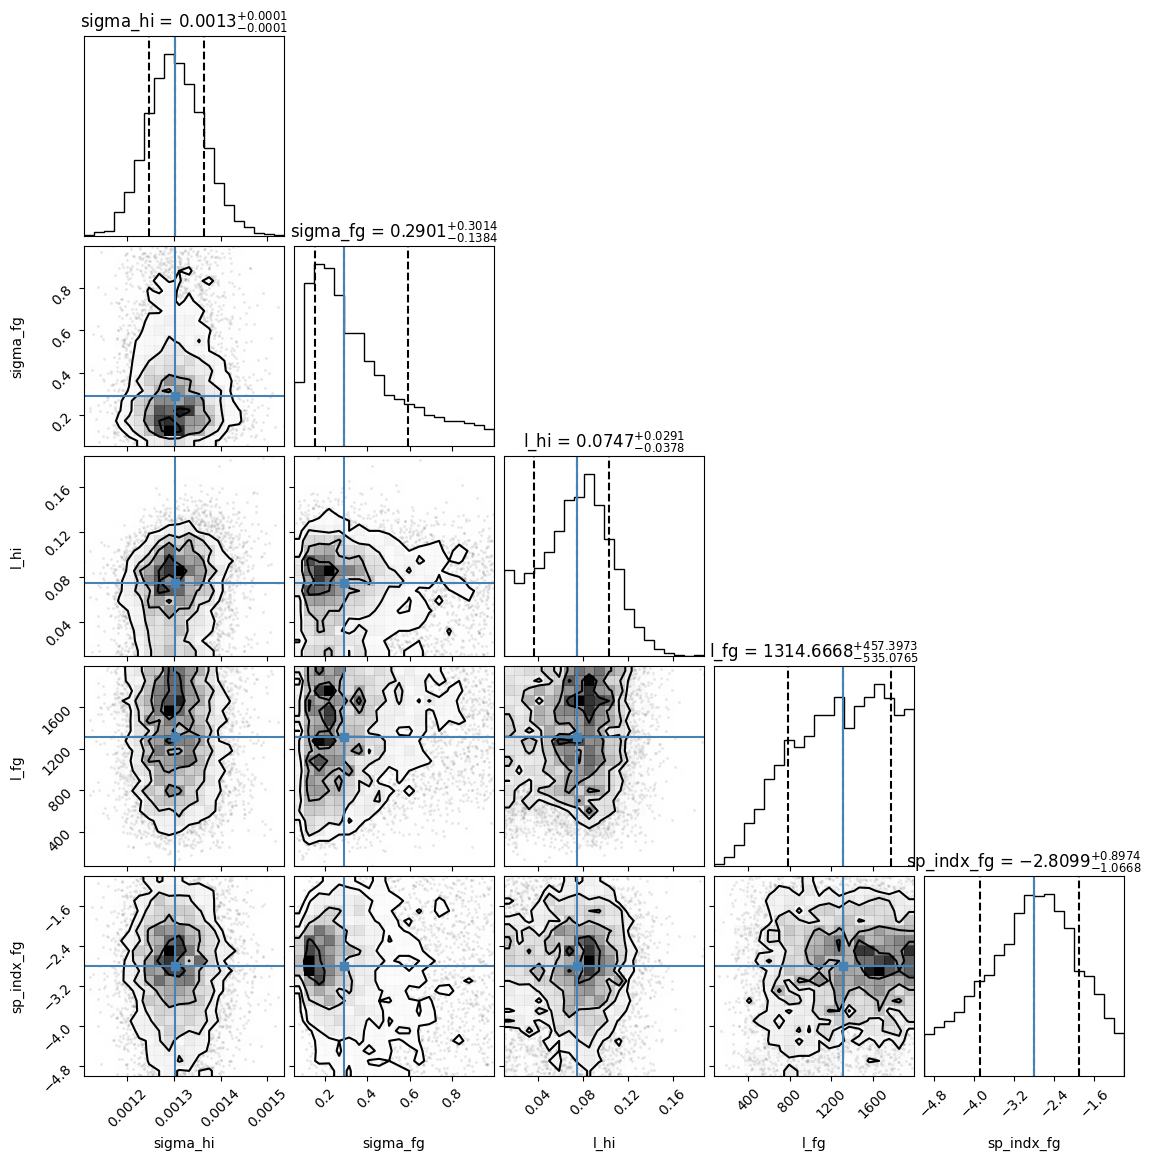

In [213]:
# corner plot
try:
    import corner
    fig = corner.corner(samples, labels=param_names, truths=medians,
                    quantiles=[0.16, 0.5, 0.84], show_titles=True,
                    title_fmt=".4f")
    fig.savefig("mcmc_corner.png", dpi=150, bbox_inches="tight")
    plt.show()
except ImportError:
    print("pip install corner to get the corner plot")

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/hi_signal_kernal_comparison_default_with_bounds1.pdf


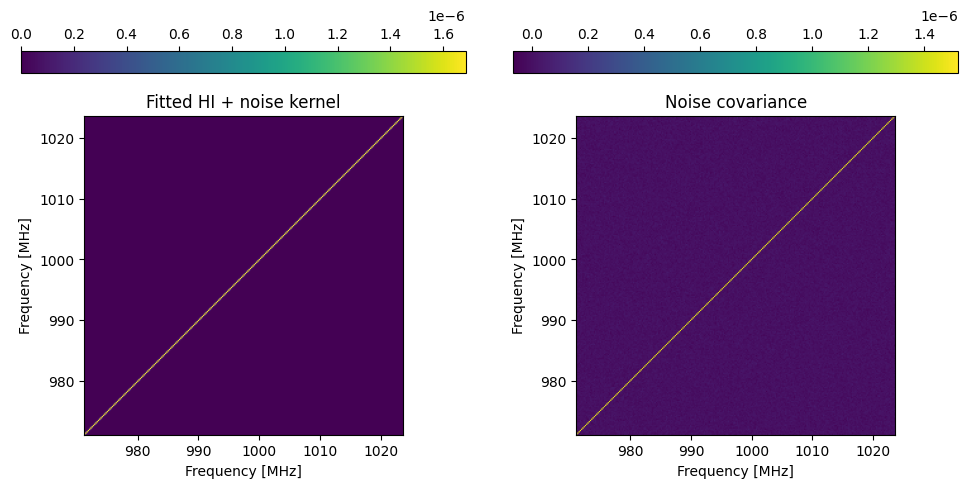

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/fg_signal_kernal_comparison_default_with_bounds1.pdf


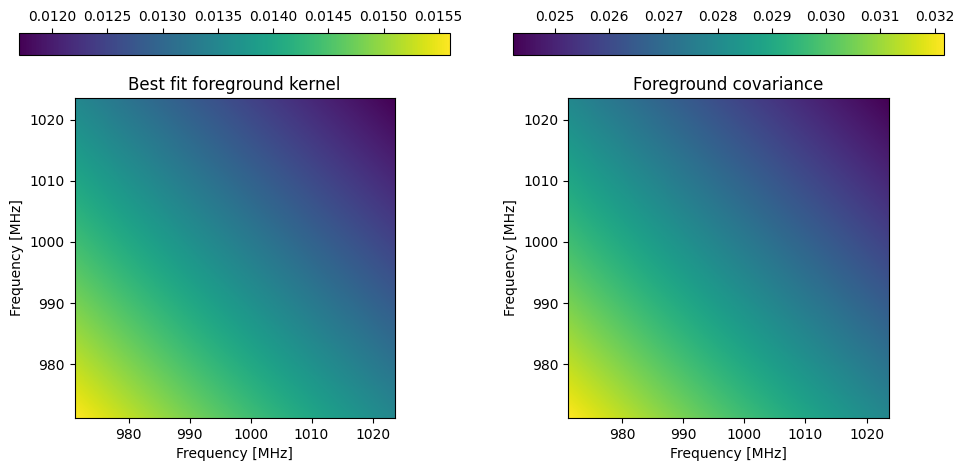

In [214]:
plot_HI_signal_kernal_comparison(best_params, method = "default_with_bounds1", save_plot = True, week_number = 5)
plot_foreground_signal_kernal_comparison(best_params, method = "default_with_bounds1", save_plot = True, week_number = 5, sp_indx_fg = True)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5, sp_indx_fg = True)

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/1d_power_spectrum_default_with_bounds1.pdf


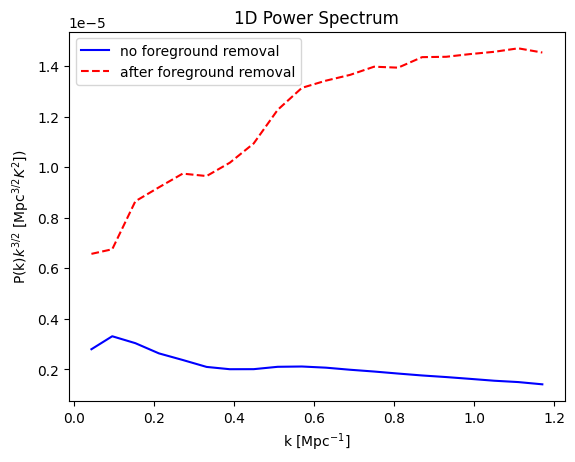

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/log_1d_power_spectrum_default_with_bounds1.pdf


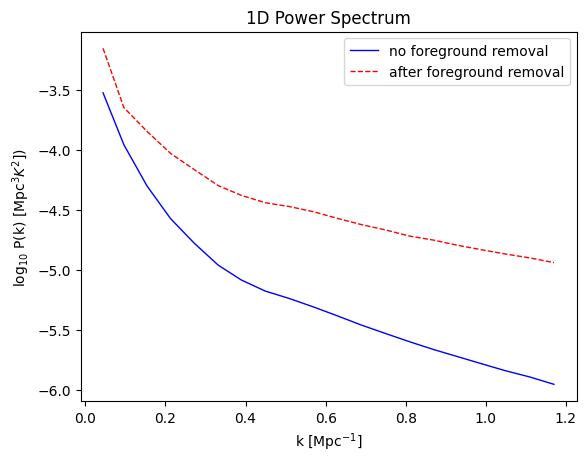

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_default_with_bounds1.pdf


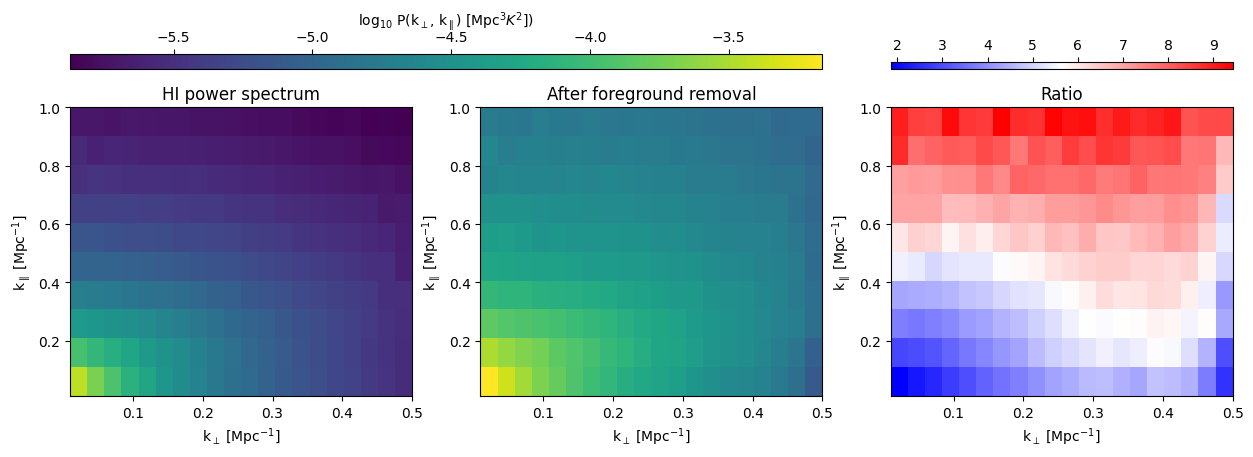

In [259]:
# With sp_indx_fg (your current model)
lml_with = function_to_optimise(map_params_with, xarr=xarr, cov_tot=cov_tot, minimise=False)

# Without sp_indx_fg
lml_without = function_to_optimise_no_sp_indx(map_params_without, xarr=xarr, cov_tot=cov_tot, minimise=False)

print(f"LML with sp_indx_fg:    {lml_with:.2f}")
print(f"LML without sp_indx_fg: {lml_without:.2f}")
print(f"Difference: {lml_with - lml_without:.2f}")

LML with sp_indx_fg:    1540.53
LML without sp_indx_fg: 1537.46
Difference: 3.08


In [ ]:
#help(pca_clean)

# Matern kernal

## Differential evolution

In [45]:
#x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
#x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg], dtype = float)
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, 2.5], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds_matern = [
    (1e-6, 0.01),   # sigma_hi
    (1e-6, 0.5),    # sigma_fg
    (0.01, 2.0),    # l_hi
    (10.0, 2000.0), # l_fg
    (0.5, 10000.0)      # eta_fg (0.5=exponential, 2.5=smooth, inf→RBF)
]
result_matern = optimize.minimize(fun = function_to_optimise_matern, x0 = x0, args = args, bounds = bounds_matern, method = 'Nelder-Mead',
    options={'maxiter': 2000, 'maxfev': 5000}) #  method = 'Nelder-Mead'

/Users/gracetait/shproject/senior_honours_project/notebooks/week5/gpr.py:8: RuntimeWarning: invalid value encountered in multiply
  sigma**2
/opt/anaconda3/envs/meer21cm/lib/python3.10/site-packages/numpy/linalg/linalg.py:2120: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


In [46]:
print(f"Success: {result_matern.success}")
print(f"Parameters: {result_matern.x}")
print(f"LML: {-result_matern.fun:.4f}")
param_names_matern = ["sigma_hi", "sigma_fg", "l_hi", "l_fg", "eta_fg"]
for name, val in zip(param_names_matern, result_matern.x):
    print(f"  {name:12s}: {val:.6f}")

best_params = result_matern.x

Success: True
Parameters: [1.27994734e-03 9.37324915e-02 1.00000000e-02 1.00000000e+01
 1.24562738e+02]
LML: 1504.3027
  sigma_hi    : 0.001280
  sigma_fg    : 0.093732
  l_hi        : 0.010000
  l_fg        : 10.000000
  eta_fg      : 124.562738


In [47]:
print(x0)
print(best_params)

[1.90448375e-04 1.82551820e-01 1.00000000e+00 4.00000000e+02
 2.50000000e+00]
[1.27994734e-03 9.37324915e-02 1.00000000e-02 1.00000000e+01
 1.24562738e+02]


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/hi_signal_kernal_comparison_default_with_bounds1.pdf


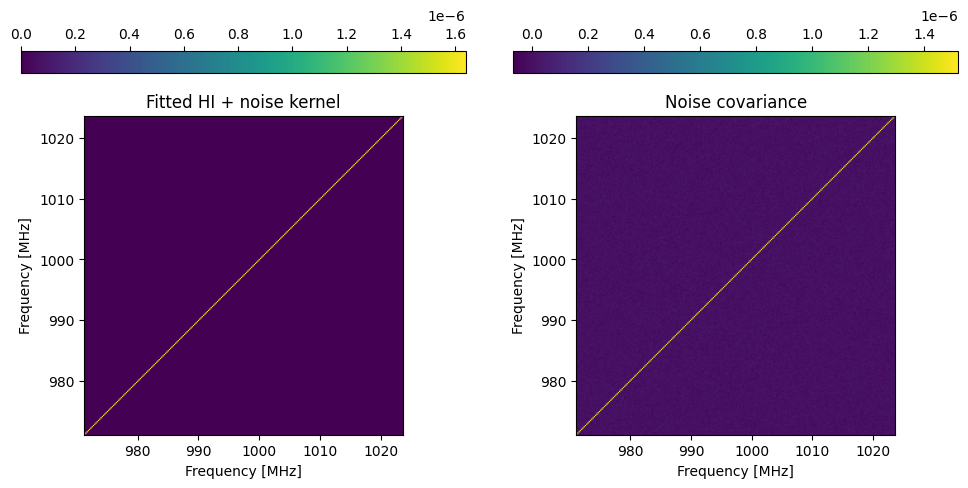

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/fg_signal_kernal_comparison_default_with_bounds1.pdf


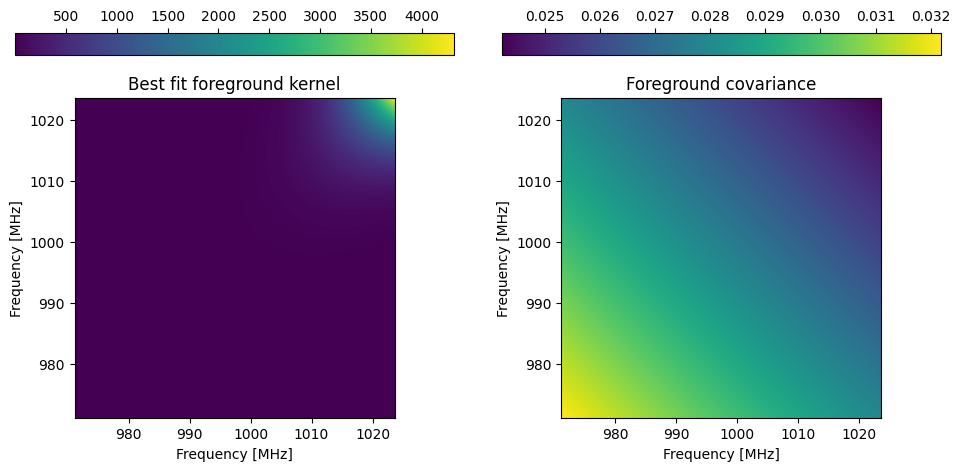

In [48]:
plot_HI_signal_kernal_comparison(best_params, method = "default_with_bounds1", save_plot = True, week_number = 5)
plot_foreground_signal_kernal_comparison(best_params, method = "default_with_bounds1", save_plot = True, week_number = 5, sp_indx_fg = True)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5, sp_indx_fg = True)

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/1d_power_spectrum_default_with_bounds1.pdf


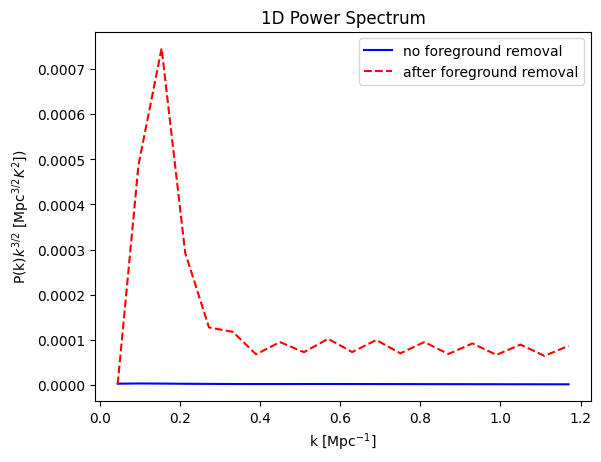

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/log_1d_power_spectrum_default_with_bounds1.pdf


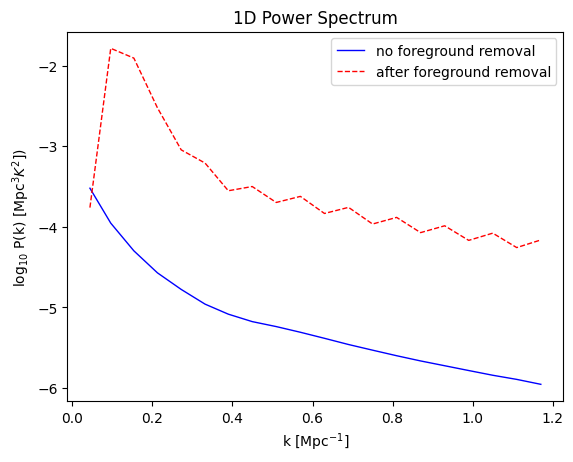

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_default_with_bounds1.pdf


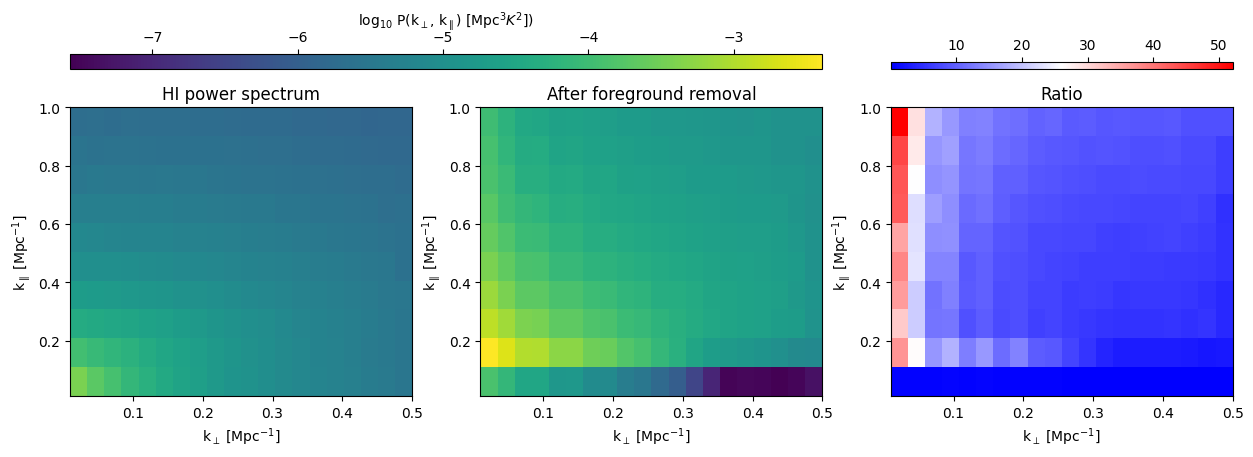

In [49]:
kernal_foreground_removal_1d_and_cylindrical_power_spectrum(best_params, method = "default_with_bounds1", save_plot = True, week_number = 5, 
                                                            sp_indx_fg = True)

## MCMC

In [ ]:
def log_prior_matern(params):
    sigma_hi, sigma_fg, l_hi, l_fg, eta_fg = params
    if (1e-6  < sigma_hi < 0.01   and
        1e-6  < sigma_fg < 0.5    and
        0.01  < l_hi     < 2.0    and
        10.0  < l_fg     < 1000.0 and
        0.5   < eta_fg   < 5.0):
        return 0.0
    return -np.inf

In [ ]:
def log_posterior_matern(params, xarr, cov_tot):
    lp = log_prior_matern(params)
    if not np.isfinite(lp):
        return -np.inf
    ll = function_to_optimise_matern(
        params, xarr=xarr, cov_tot=cov_tot, minimise=False
    )
    return lp + ll if np.isfinite(ll) else -np.inf


In [ ]:
# Initialise walkers around differential evolution result
x0_matern = result_matern.x
ndim      = len(x0_matern)
nwalkers  = 40
nburn     = 500
nsteps    = 5000

rng = np.random.default_rng(42)
p0  = x0_matern[None, :] + 1e-3 * rng.standard_normal((nwalkers, ndim)) * x0_matern[None, :]

In [ ]:
# Run sampler
sampler_matern = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior_matern,
    args=(xarr, cov_tot)
)

print("Burning in …")
import time
start = time.time()
for i, result in enumerate(sampler_matern.sample(p0, iterations=nburn)):
    if (i + 1) % 50 == 0:
        elapsed = time.time() - start
        remaining = elapsed / (i + 1) * (nburn - i - 1)
        print(f"  Burn-in step {i+1}/{nburn} | "
              f"elapsed: {elapsed/60:.1f}m | "
              f"remaining: {remaining/60:.1f}m")
state = result
sampler_matern.reset()

print("Sampling …")
start = time.time()
for i, _ in enumerate(sampler_matern.sample(state, iterations=nsteps)):
    if (i + 1) % 100 == 0:
        elapsed = time.time() - start
        remaining = elapsed / (i + 1) * (nsteps - i - 1)
        print(f"  Sample step {i+1}/{nsteps} | "
              f"elapsed: {elapsed/60:.1f}m | "
              f"remaining: {remaining/60:.1f}m")

In [ ]:
# Extract and save results
tau = sampler_matern.get_autocorr_time(quiet=True)
thin = max(1, int(tau.min() / 2))
samples_matern = sampler_matern.get_chain(flat=True, thin=thin)
log_prob_matern = sampler_matern.get_log_prob(flat=True, thin=thin)

best_idx       = np.argmax(log_prob_matern)
map_params_matern = samples_matern[best_idx]

In [ ]:
# Save immediately
np.save('mcmc_samples_matern.npy', samples_matern)
np.save('mcmc_log_probs_matern.npy', log_prob_matern)
np.save('mcmc_map_params_matern.npy', map_params_matern)

In [ ]:
# Results
medians = np.median(samples_matern, axis=0)
stds    = np.std(samples_matern, axis=0)
print("\nResults:")
for name, med, std in zip(param_names_matern, medians, stds):
    print(f"  {name:12s}: {med:.4f} ± {std:.4f}")
print(f"\nMAP params: {dict(zip(param_names_matern, map_params_matern))}")

In [ ]:
# Corner plot
import corner, matplotlib.pyplot as plt
fig = corner.corner(samples_matern, labels=param_names_matern, truths=medians,
                    quantiles=[0.16, 0.5, 0.84], show_titles=True, title_fmt=".4f")
fig.savefig("mcmc_corner_matern.png", dpi=150, bbox_inches="tight")
plt.show()